# QC: Conditional Diffusion Model Comparison

Compare two training scenarios for conditional facies generation from RMS amplitude:

| Scenario | `predict_type` | Run ID | Description |
|---|---|---|---|
| **A** | `epsilon` | `20260507_141532` | Model predicts noise (ε), subtract to get image |
| **B** | `x_start` | `20260510_112719` | Model predicts output image (x₀) directly |

Both models share the same UNet architecture, beta schedule, and training hyperparameters.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../scripts'))

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150

from flumy_check_results import (
    ResultsQC,
    load_3d_cube,
    plot_3d_facies_9class,
    plot_3d_facies_reclassification,
    plot_facies_to_rms_pipeline,
    plot_slicing_and_cropping,
    plot_diffusion_training_schematic,
    plot_3d_cube_orthogonal,
    plot_predict_type_explanation,
    plot_cube_3d,
    FACIES_CMAP, FACIES_NORM,
)

/home/tharitt/working/DiffSim/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
# Part A: Slide Figures (Data Pipeline)
---

## Slide 1: 3D Facies – 9 Original Classes → 3 Reclassified
Load a 3D Flumy cube and show the original 9-facies classification alongside the simplified 3-class version.

In [3]:
# Load a 3D cube
facies_3d, rms_3d = load_3d_cube(
    cube_name="ng50_isbx80_seed6",
    data_dir="/mnt/sda_data/tharitt/diffsim/data/flumy3d",
)
print(f"Facies shape: {facies_3d.shape}, RMS shape: {rms_3d.shape}")

Facies shape: (256, 256, 30), RMS shape: (256, 256, 29)


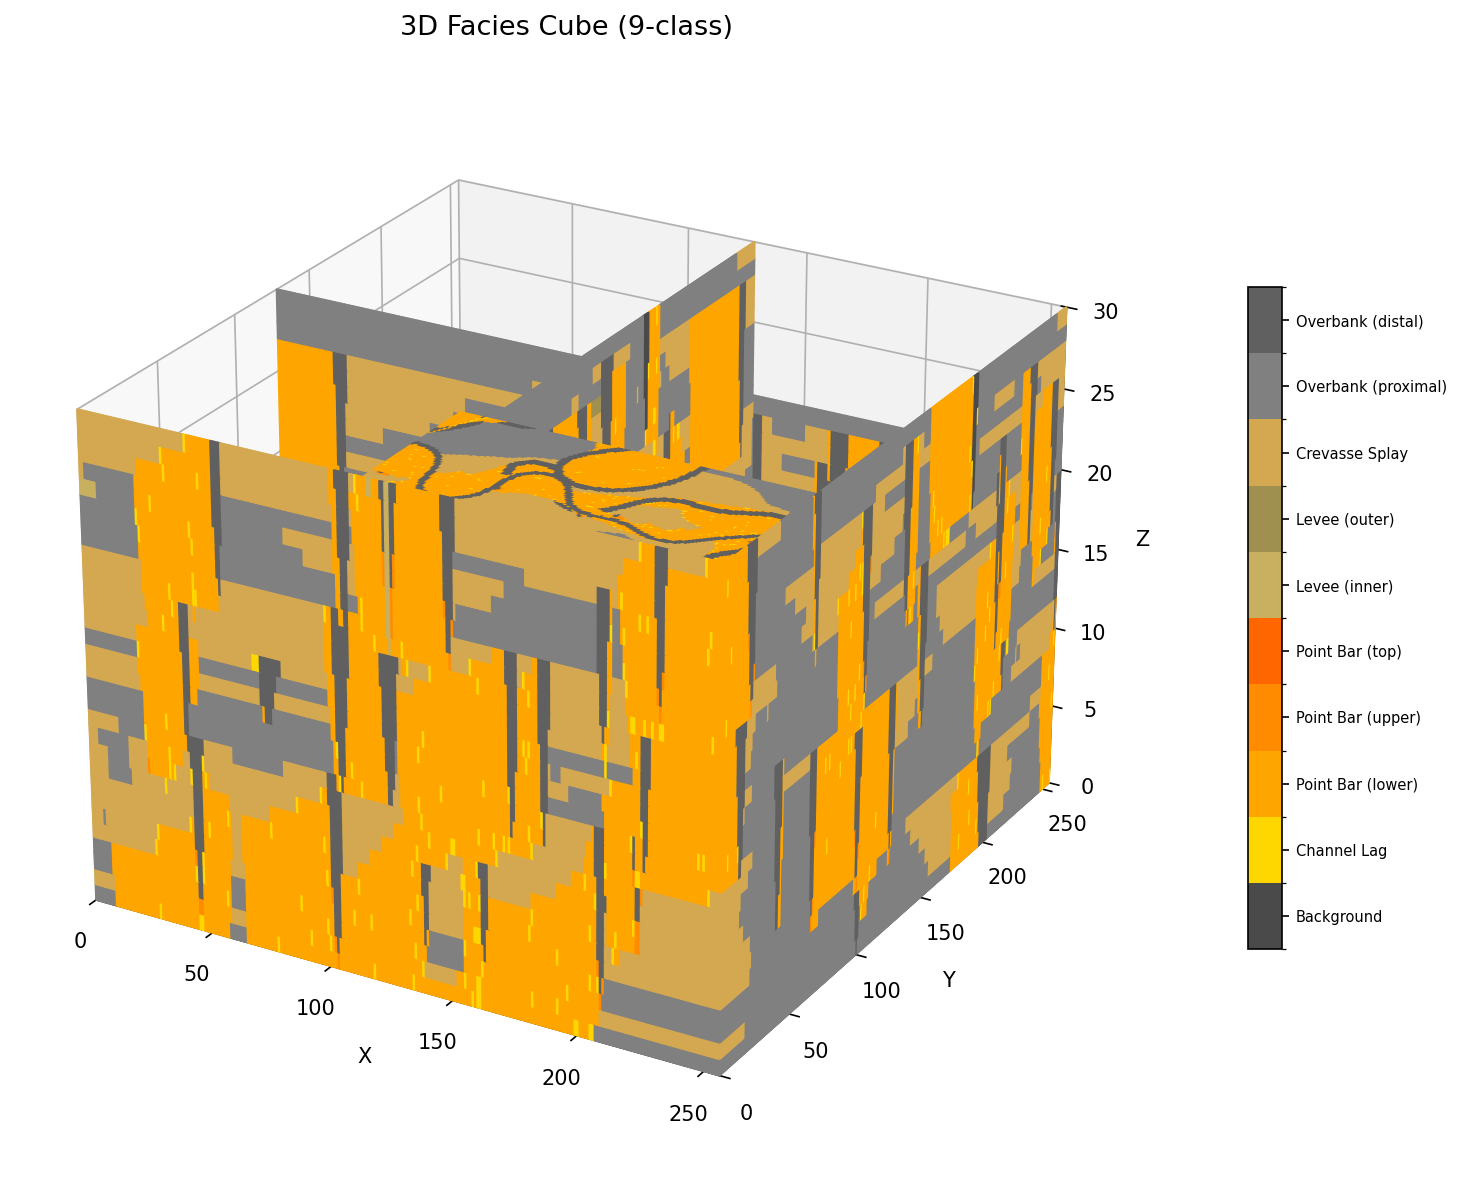

In [4]:
fig = plot_cube_3d(facies_3d, facies_9class=True, title="3D Facies Cube (9-class)")

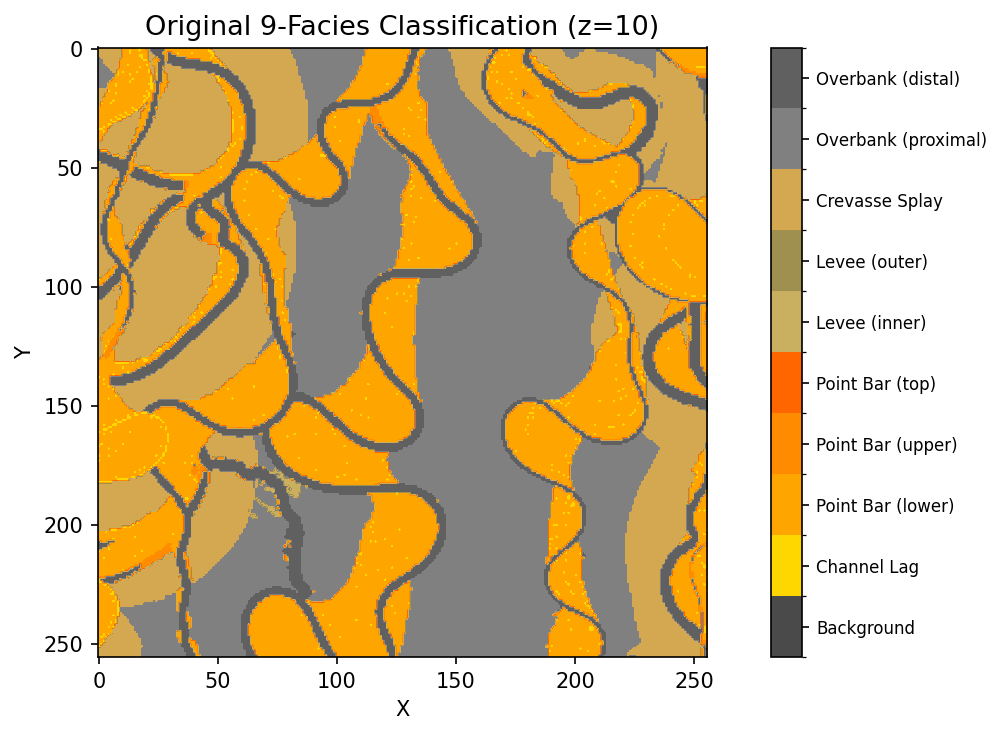

In [5]:
# 9-class facies (original Flumy output)
fig = plot_3d_facies_9class(facies_3d, z_index=10,
    # save_path="../assets/slide1a_9class.png",
)

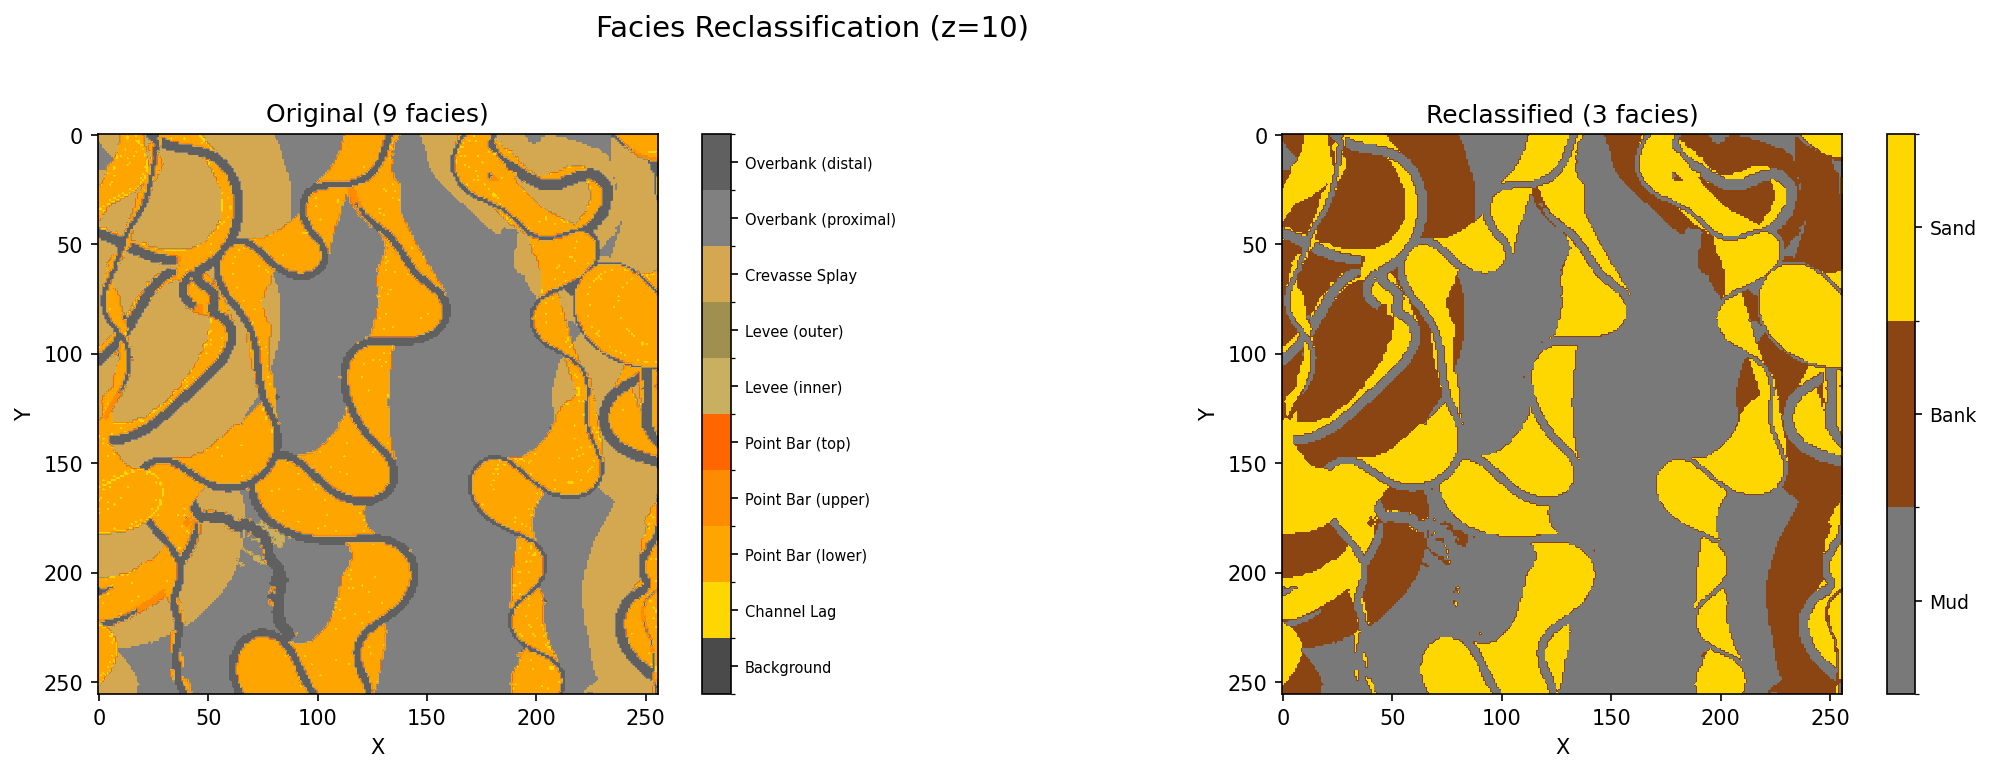

In [6]:
# Side-by-side: 9-class → 3-class reclassification
fig = plot_3d_facies_reclassification(facies_3d, z_index=10,
    # save_path="../assets/slide1b_reclassification.png",
)

## Slide 2: Seismic Forward Modeling (Facies → RMS)
Show how 3D facies is converted to RMS amplitude through the rock physics pipeline.

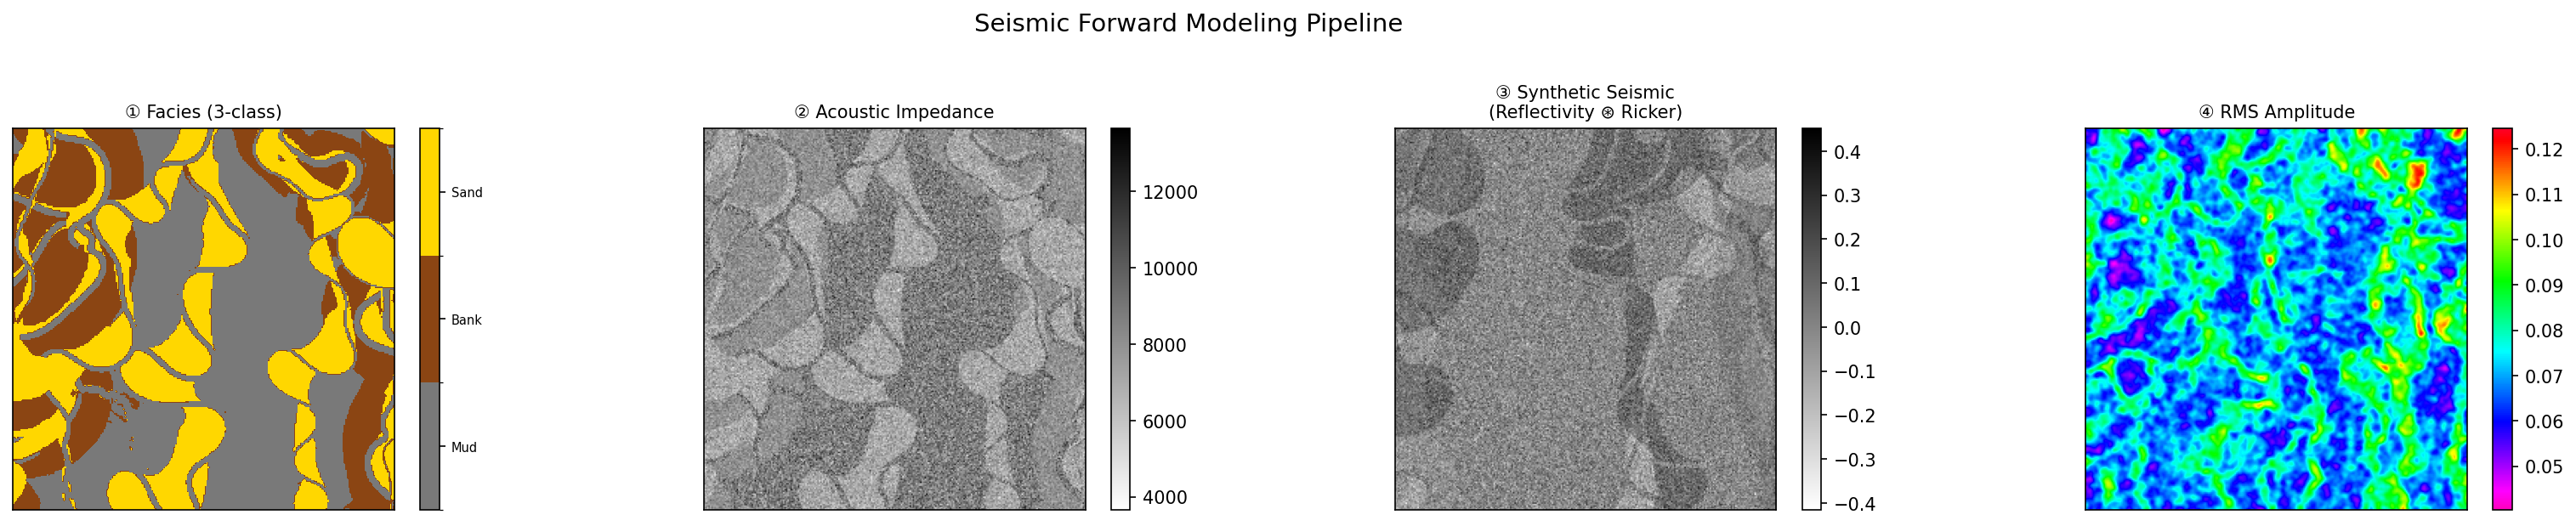

In [7]:
# Facies → AI → Reflectivity → Synthetic Seismic → RMS
fig = plot_facies_to_rms_pipeline(facies_3d, rms_3d, z_index=10,
    # save_path="../assets/slide2_seismic_pipeline.png",
)

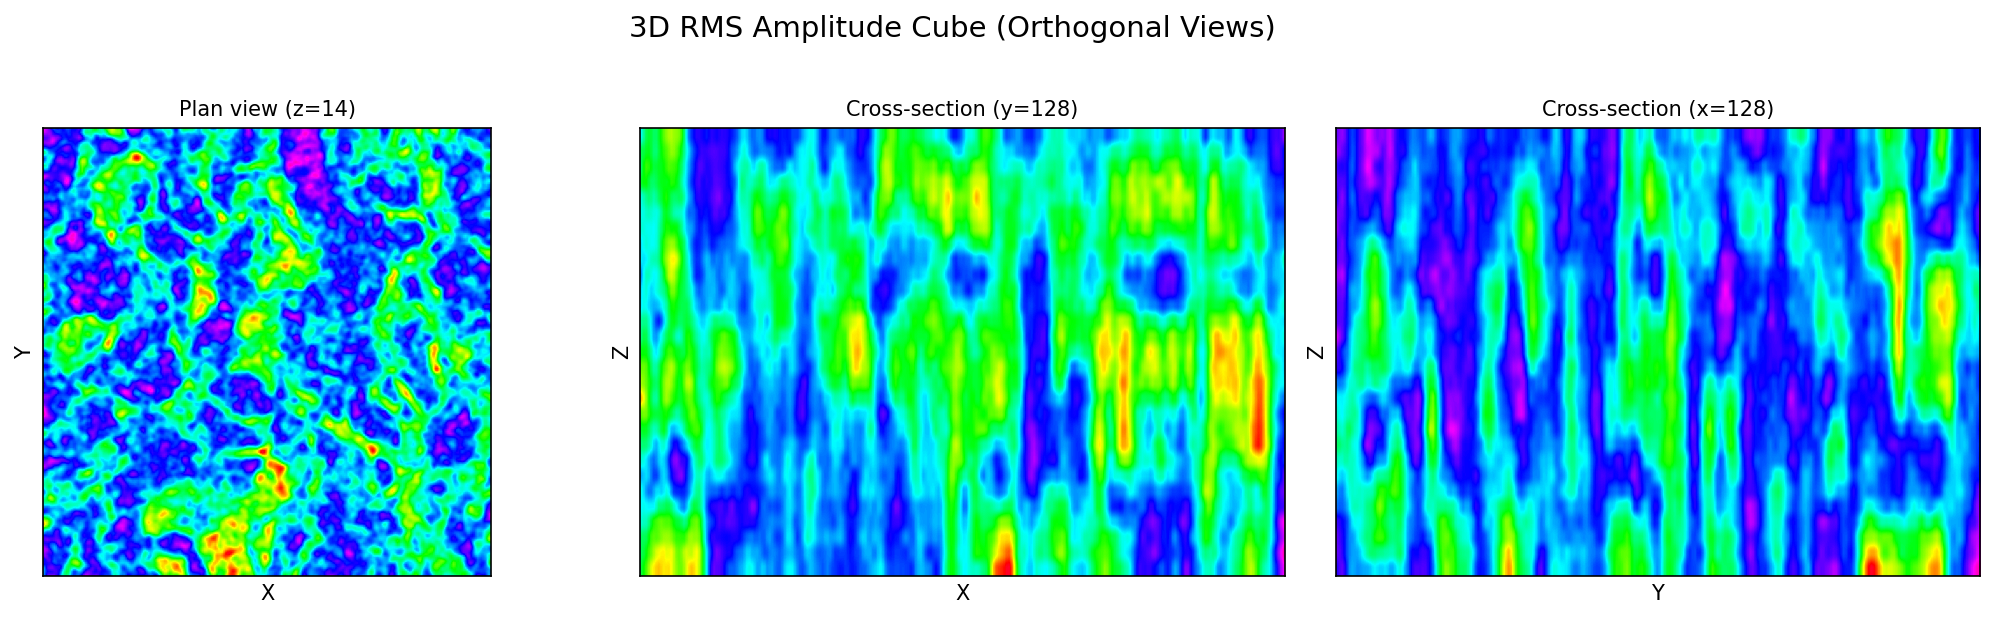

In [8]:
# Orthogonal views of the 3D RMS cube
fig = plot_3d_cube_orthogonal(rms_3d, cmap="gist_rainbow_r",
    title="3D RMS Amplitude Cube (Orthogonal Views)",
    # save_path="../assets/slide2b_rms_cube_ortho.png",
)

## Slide 3: Slicing & Random Cropping (3D → 2D patches)
Show how a depth slice is extracted from the cube and randomly cropped into 64×64 training pairs.

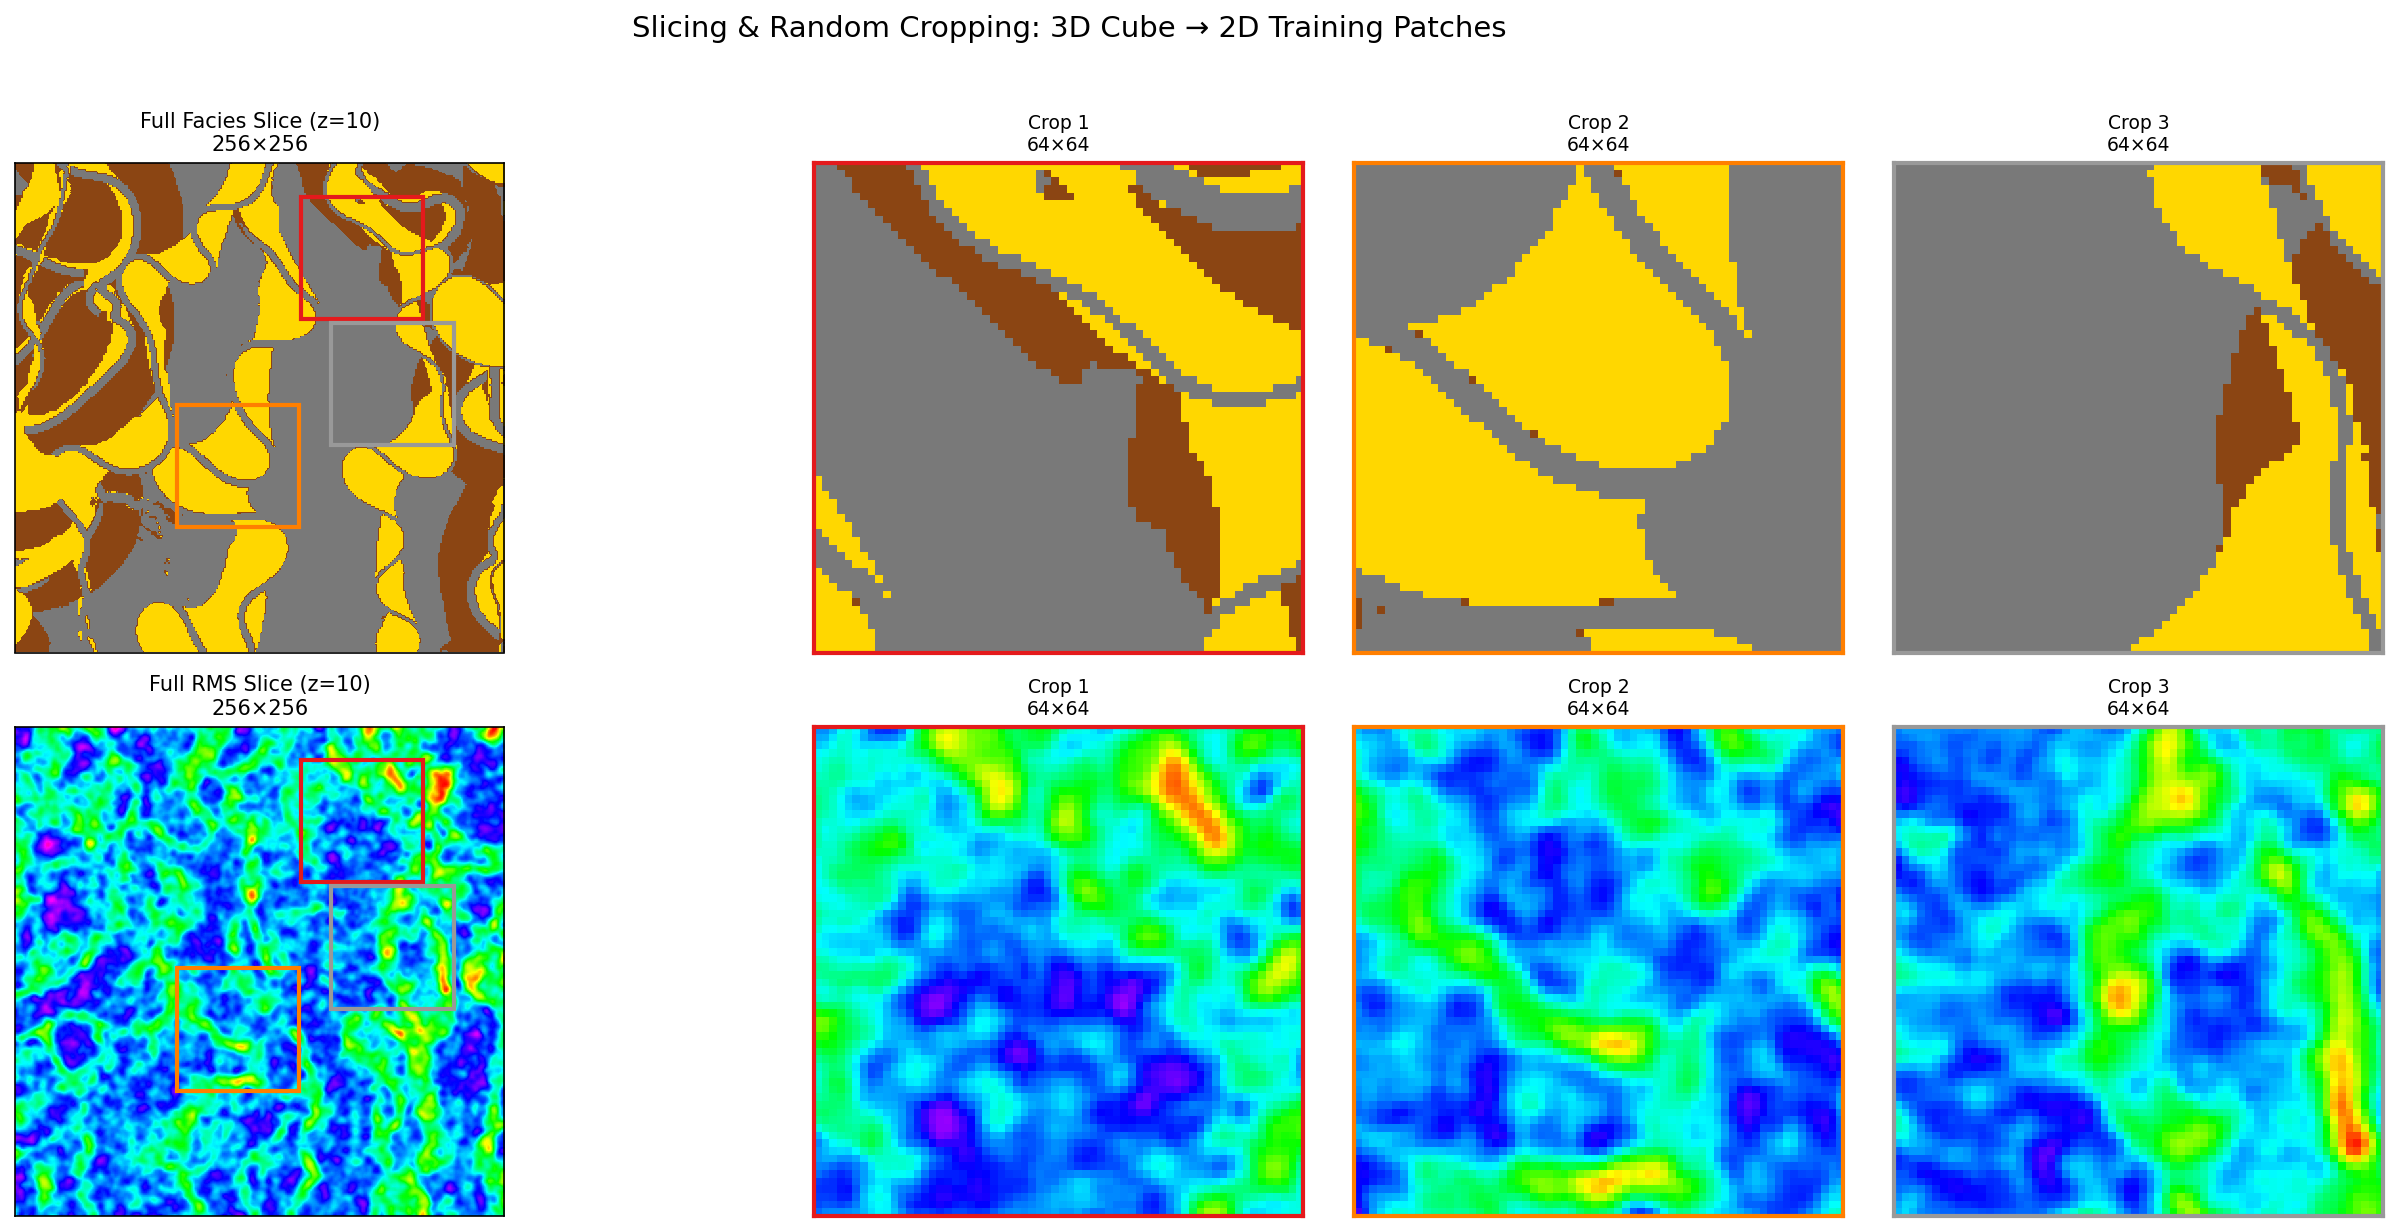

In [9]:
# Full slice → random 64x64 crops (facies + RMS pairs)
fig = plot_slicing_and_cropping(facies_3d, rms_3d, z_index=10,
    crop_size=64, num_crops=3, seed=42,
    # save_path="../assets/slide3_slicing_cropping.png",
)

## Slide 4: Conditional Diffusion Training Schematic
Illustrate how 2D 64×64 facies patches + RMS conditioning are fed into the diffusion network.

In [10]:
# Forward/reverse diffusion process visualization
# get z=10
fig = plot_diffusion_training_schematic(
    num_noise_levels=5,
    # save_path="../assets/slide4_diffusion_schematic.png",
)

IndexError: list index out of range

In [ ]:
# Explanation diagram: predict-noise vs predict-image
fig = plot_predict_type_explanation(
    # save_path="../assets/slide4b_predict_type_explanation.png",
)

---
# Part B: Model QC & Comparison (Loss, Inference, Results)
---

## 1. Initialize QC Object

In [11]:
qc = ResultsQC(

    run_epsilon ="20260513_112608",
    run_xstart ="20260513_112608",
    # run_epsilon="20260507_141532",
    # run_xstart="20260513_112608",
    base_dir="/mnt/sda_data/tharitt/diffsim",
)
print(f"Test dataset: {len(qc.test_dataset)} samples")
print(f"Image size: {qc.image_size}x{qc.image_size}")
print(f"Device: {qc.device}")

Data config from model config: {'train_image': '/mnt/sda_data/tharitt/diffsim/data/flumy_dataset/train', 'test_image': '/mnt/sda_data/tharitt/diffsim/data/flumy_dataset/test'}
Test dataset path from config: /mnt/sda_data/tharitt/diffsim/data/flumy_dataset/test
Loading test dataset from: /mnt/sda_data/tharitt/diffsim/data/flumy_dataset/test
Test dataset: 43200 samples
Image size: 64x64
Device: cuda


## 2. Training Loss Curves
Read TensorBoard event files and plot smoothed training/validation loss.

In [7]:
# NOTE: takes longer to run
fig = qc.plot_losses(
    smoothing=0.95,
    figsize=(14, 5),
    # save_path="../assets/loss_comparison.png",
)

KeyboardInterrupt: 

## 3. Input Data Overview
Show ground truth facies maps and their RMS conditioning inputs.

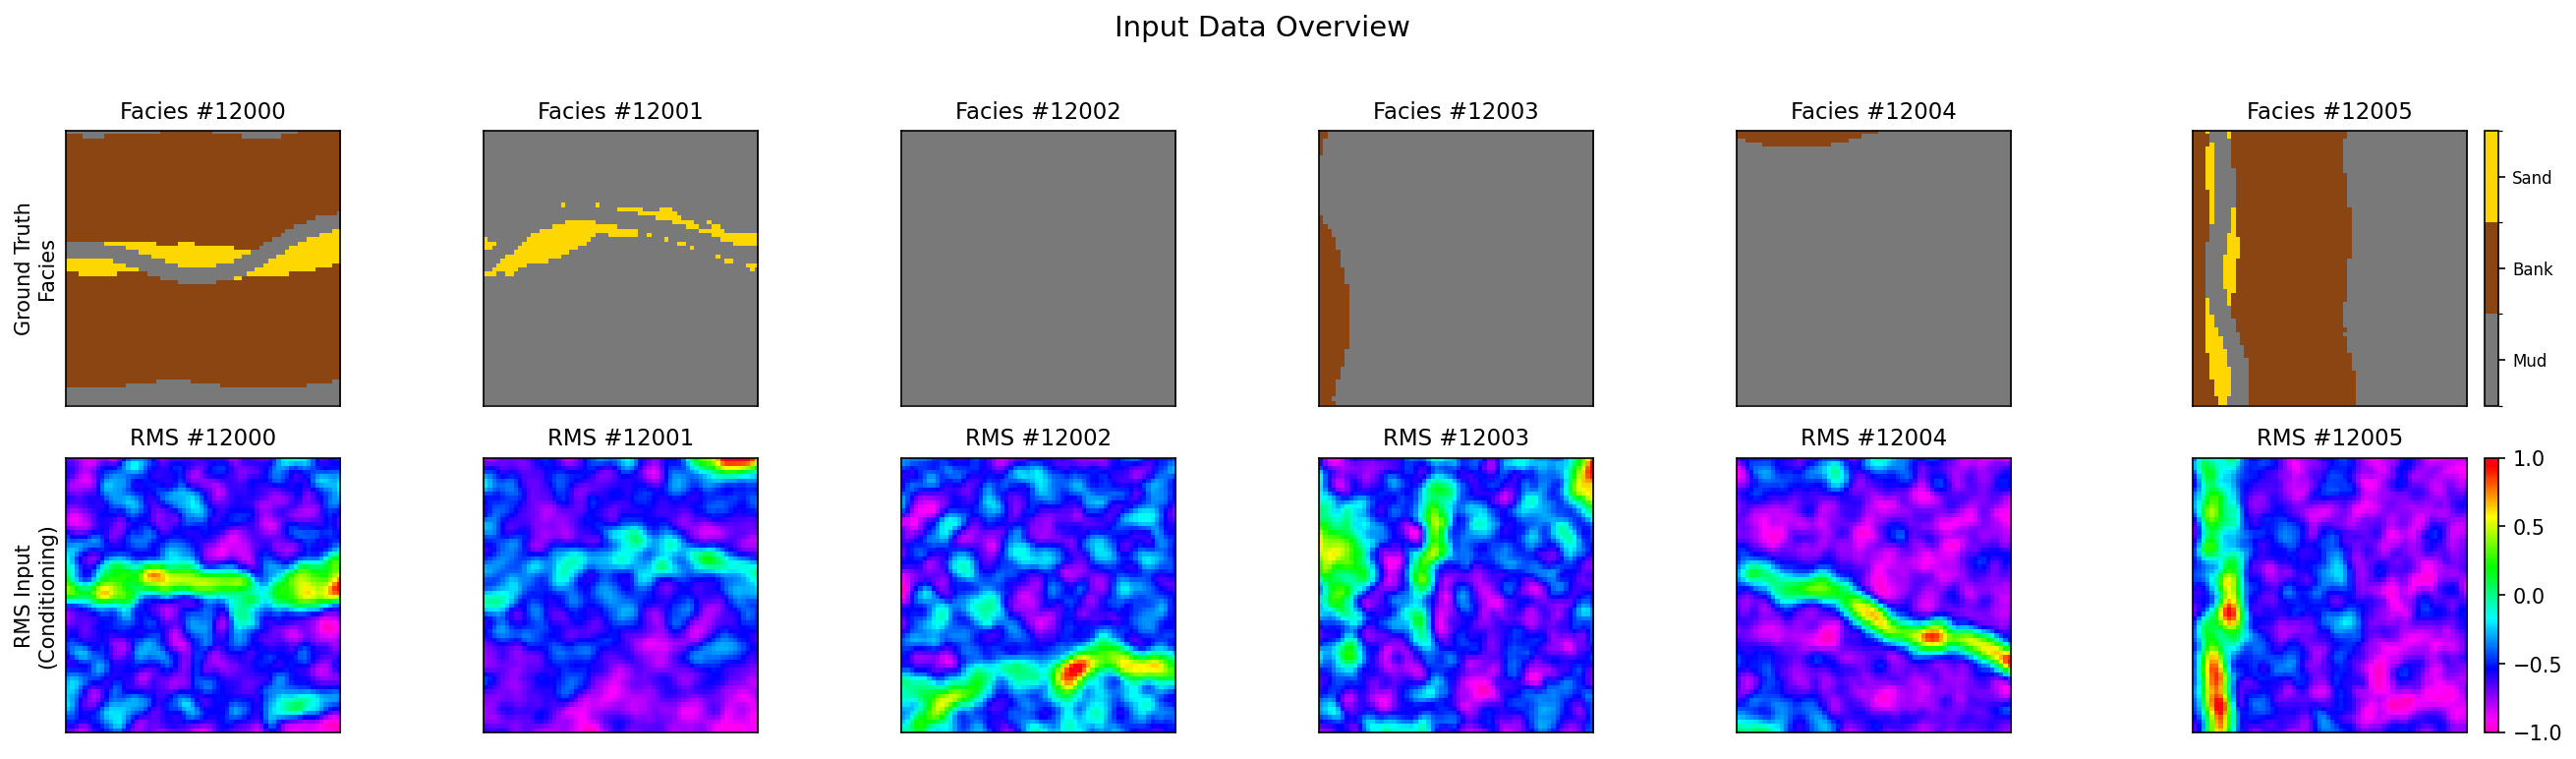

In [8]:
fig = qc.plot_input_data(
    index=12000,
    num_samples=6,
    figsize=(18, 5),
    # save_path="../assets/input_data_overview.png",
)

## 4. Single-Sample Inference Comparison
Run both models on a test sample and compare side-by-side with the ground truth.

DDIM Sampling: 100%|██████████| 50/50 [00:00<00:00, 132.17it/s]


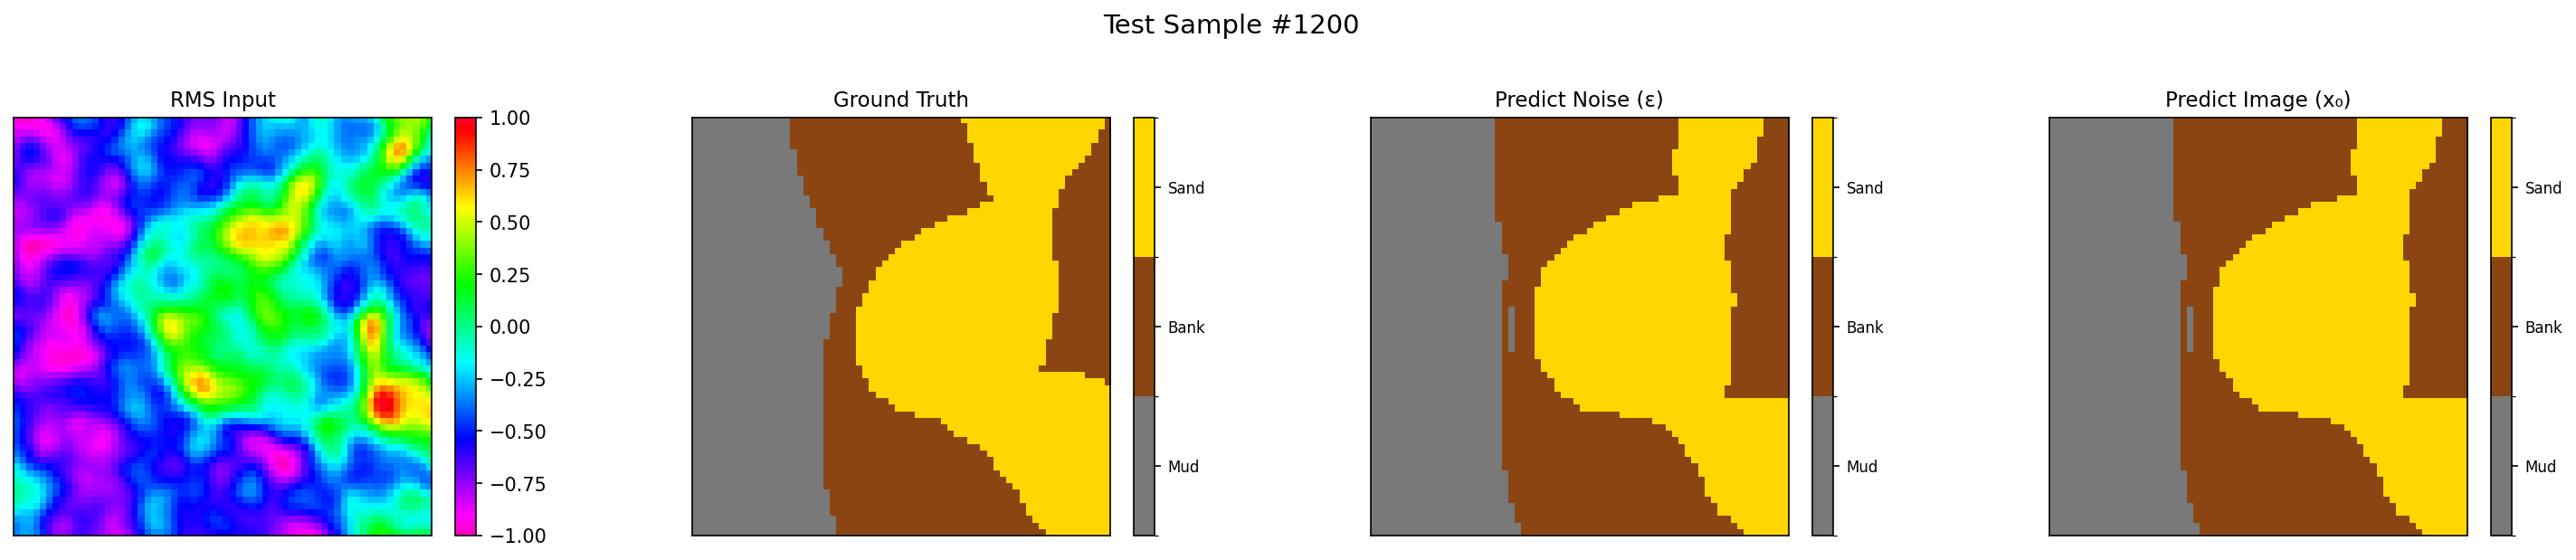

DDIM Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

DDIM Sampling: 100%|██████████| 50/50 [00:00<00:00, 133.37it/s]


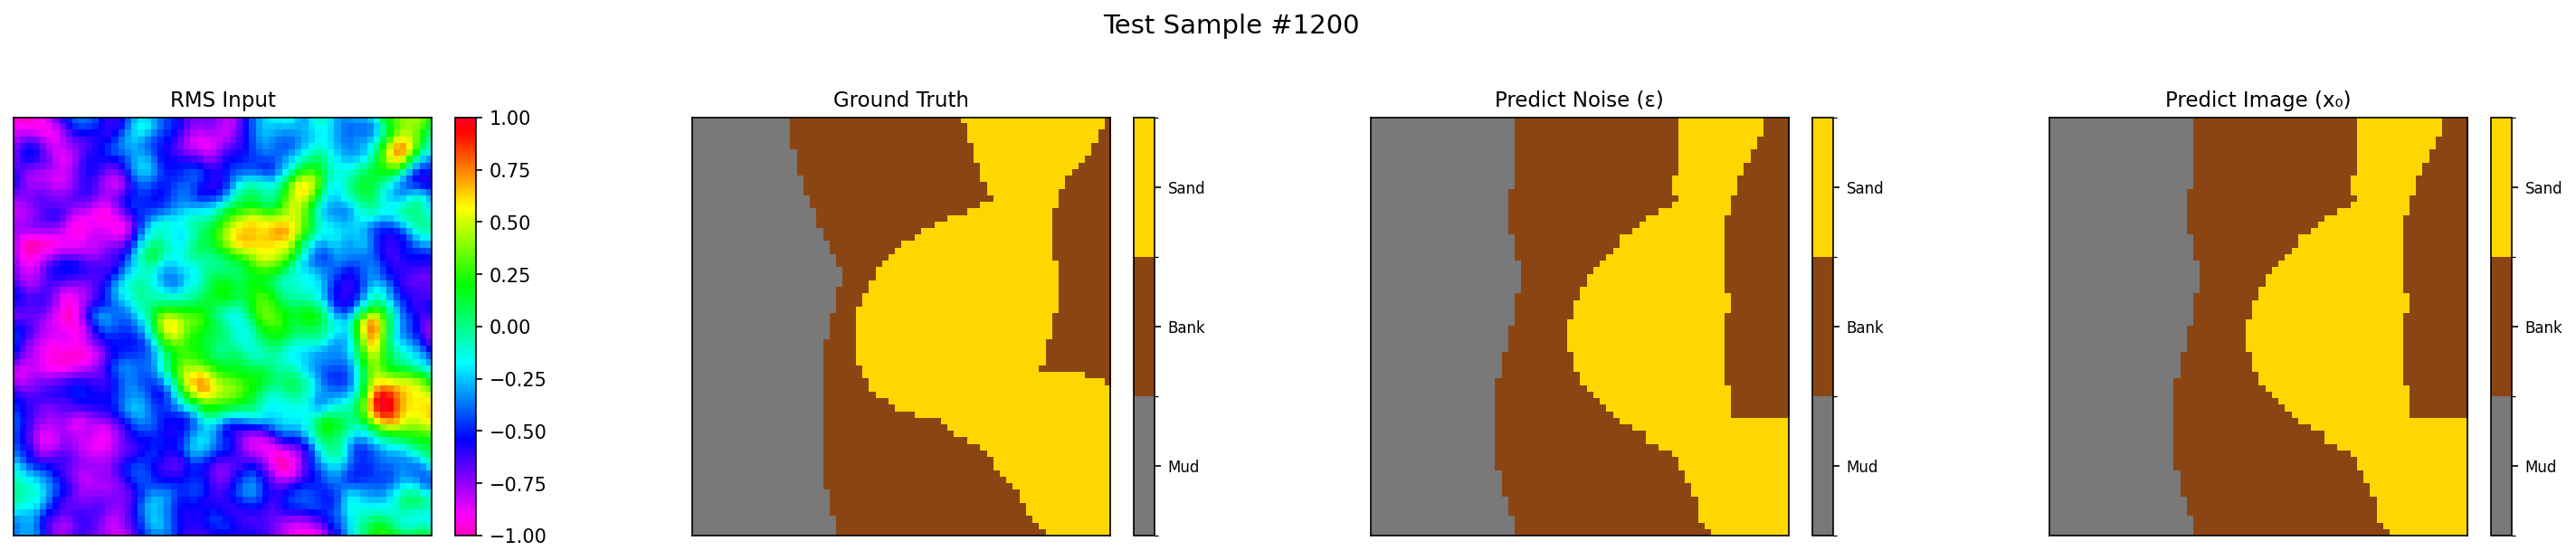

DDIM Sampling: 100%|██████████| 50/50 [00:00<00:00, 135.89it/s]


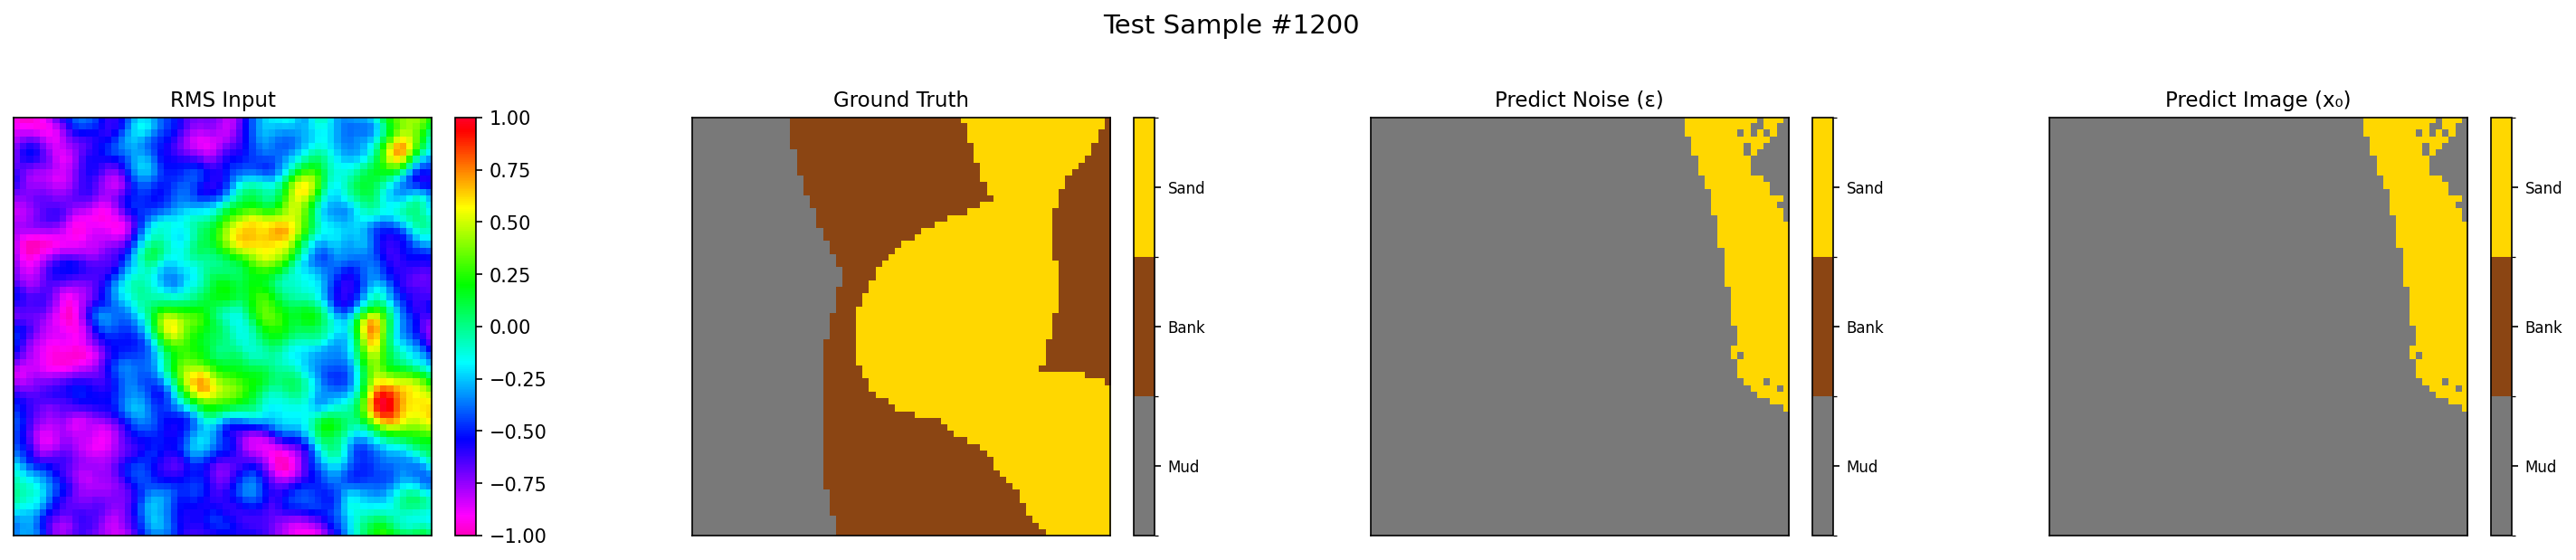

DDIM Sampling: 100%|██████████| 50/50 [00:00<00:00, 134.59it/s]


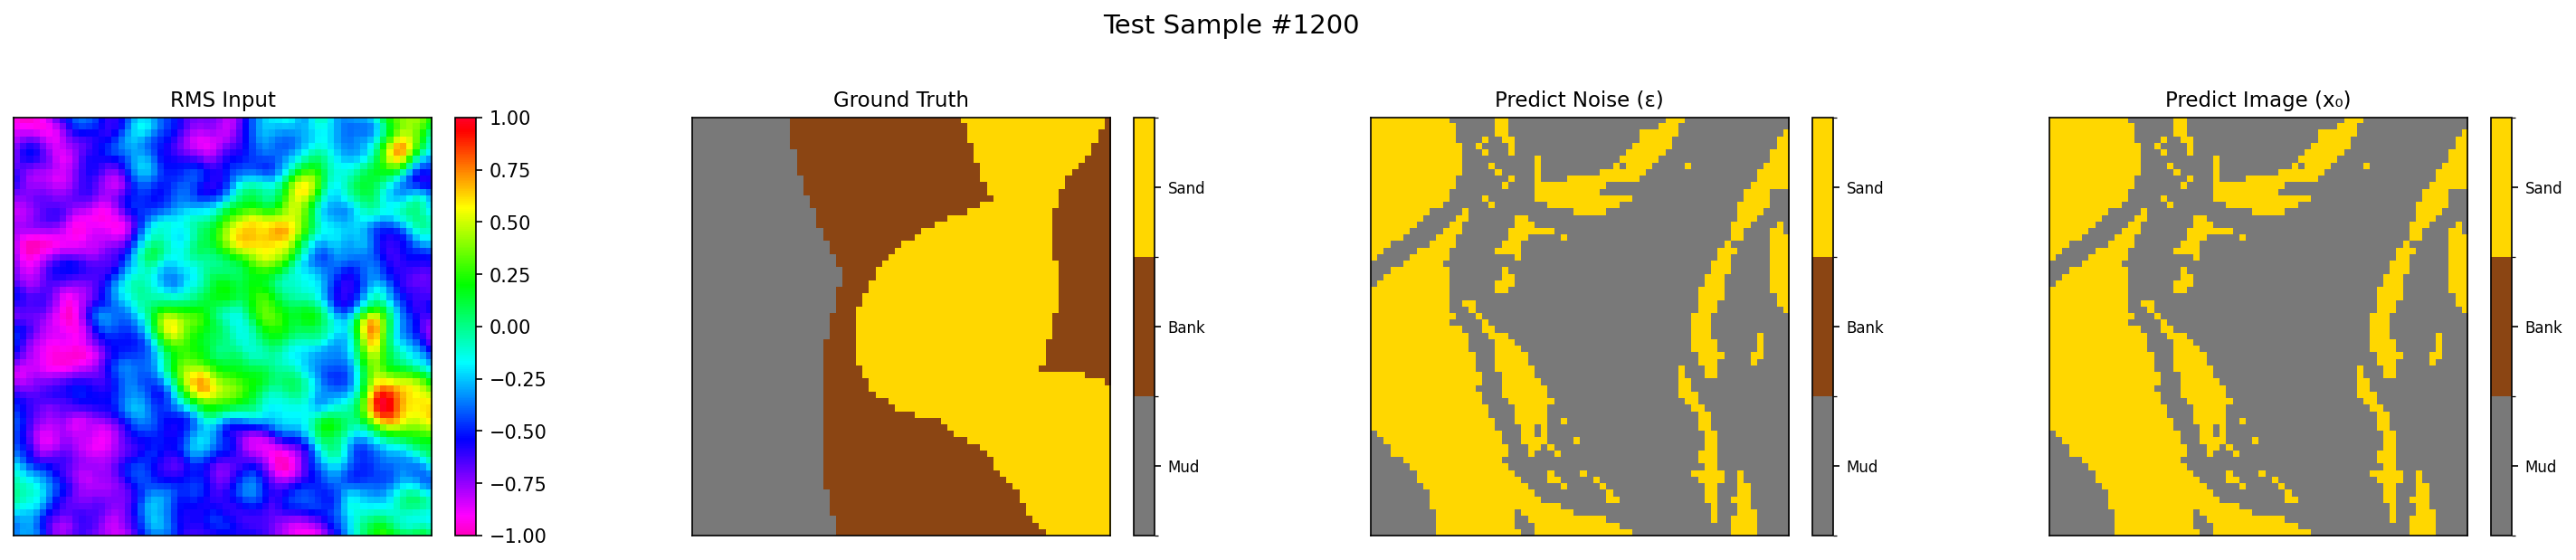

DDIM Sampling: 100%|██████████| 50/50 [00:00<00:00, 135.26it/s]


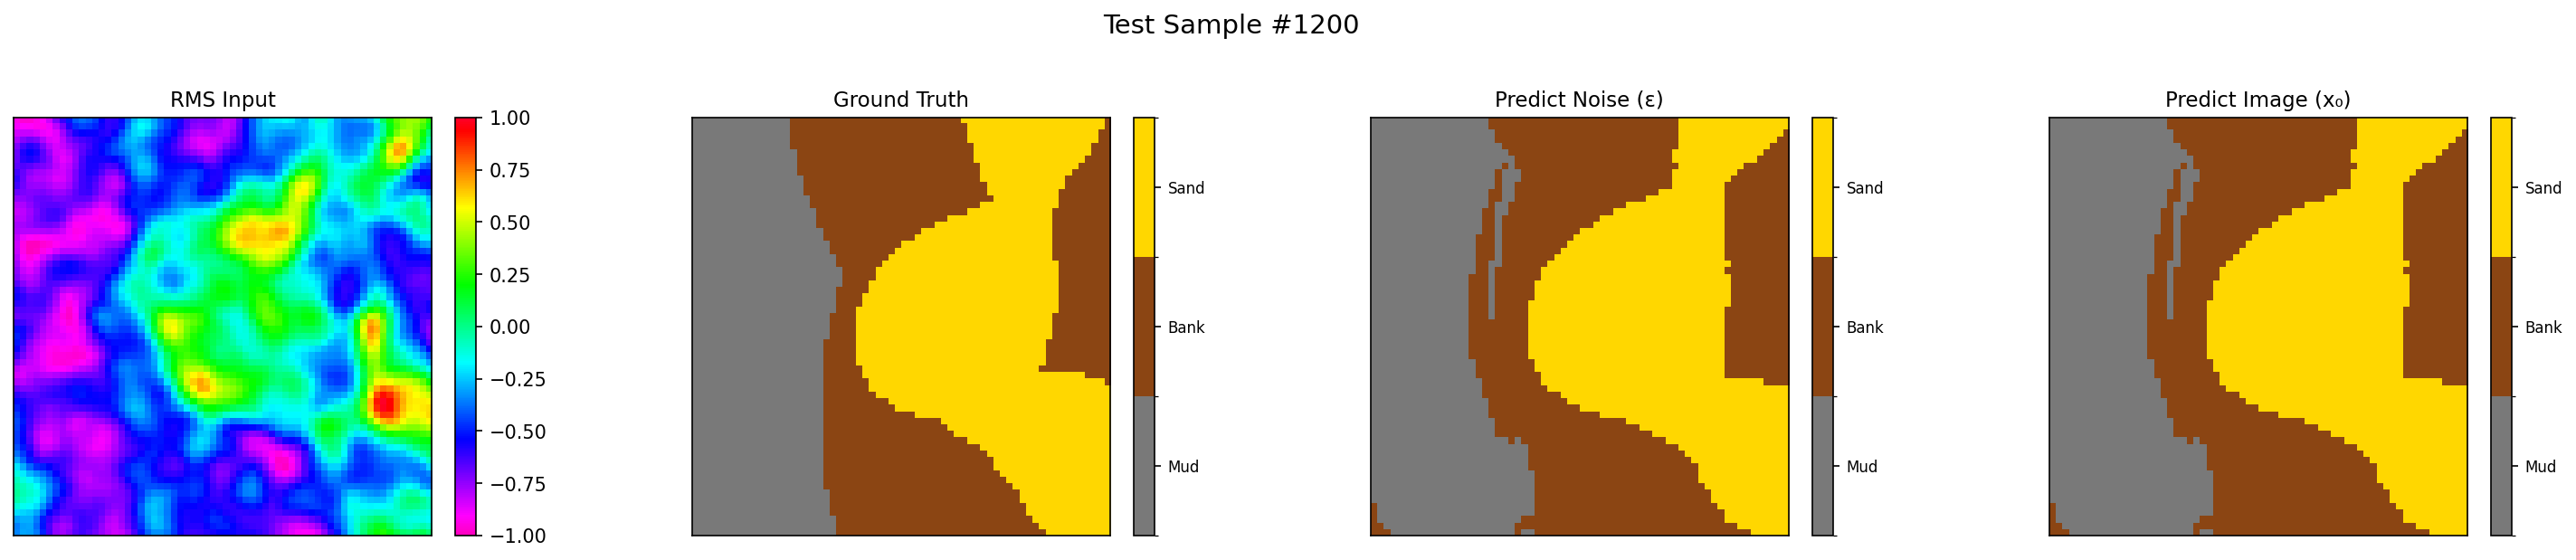

DDIM Sampling: 100%|██████████| 50/50 [00:00<00:00, 136.56it/s]


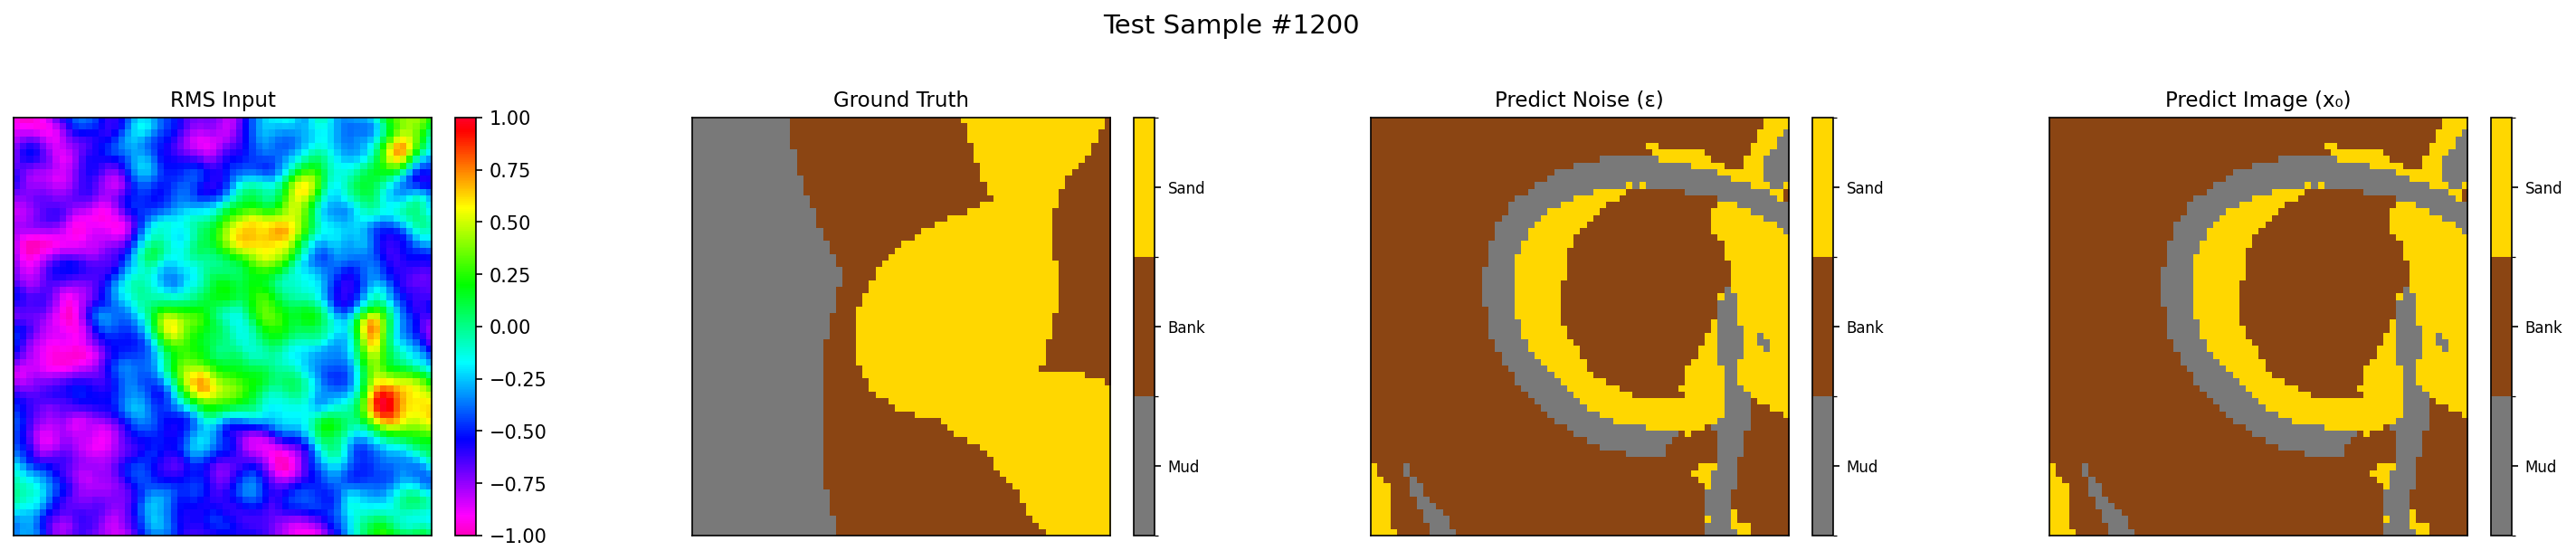

DDIM Sampling: 100%|██████████| 50/50 [00:00<00:00, 134.54it/s]


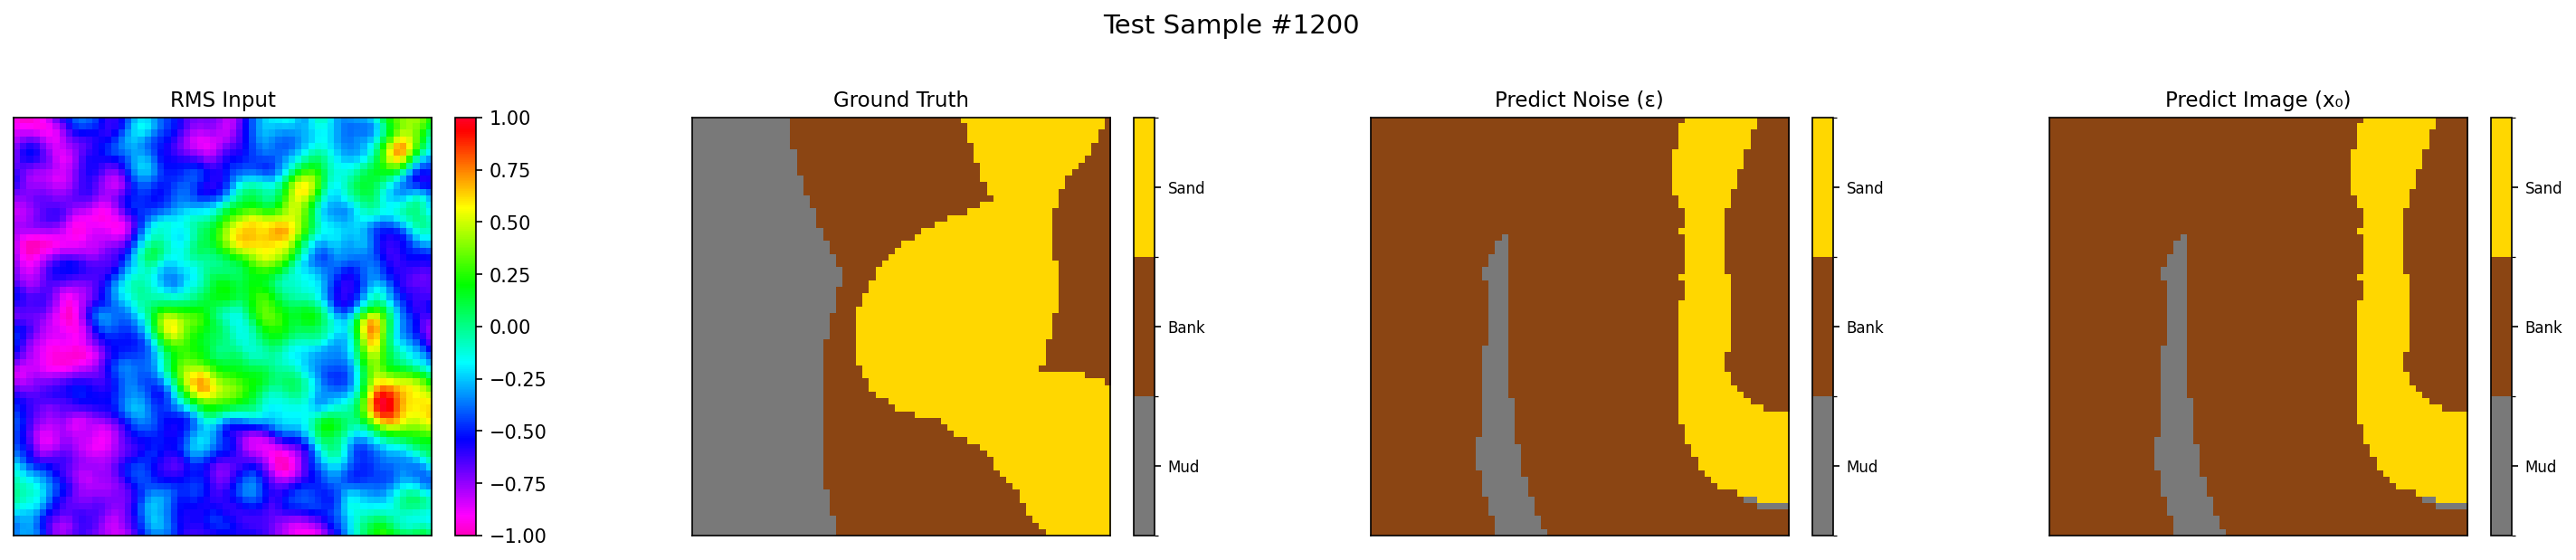

DDIM Sampling: 100%|██████████| 50/50 [00:00<00:00, 133.82it/s]


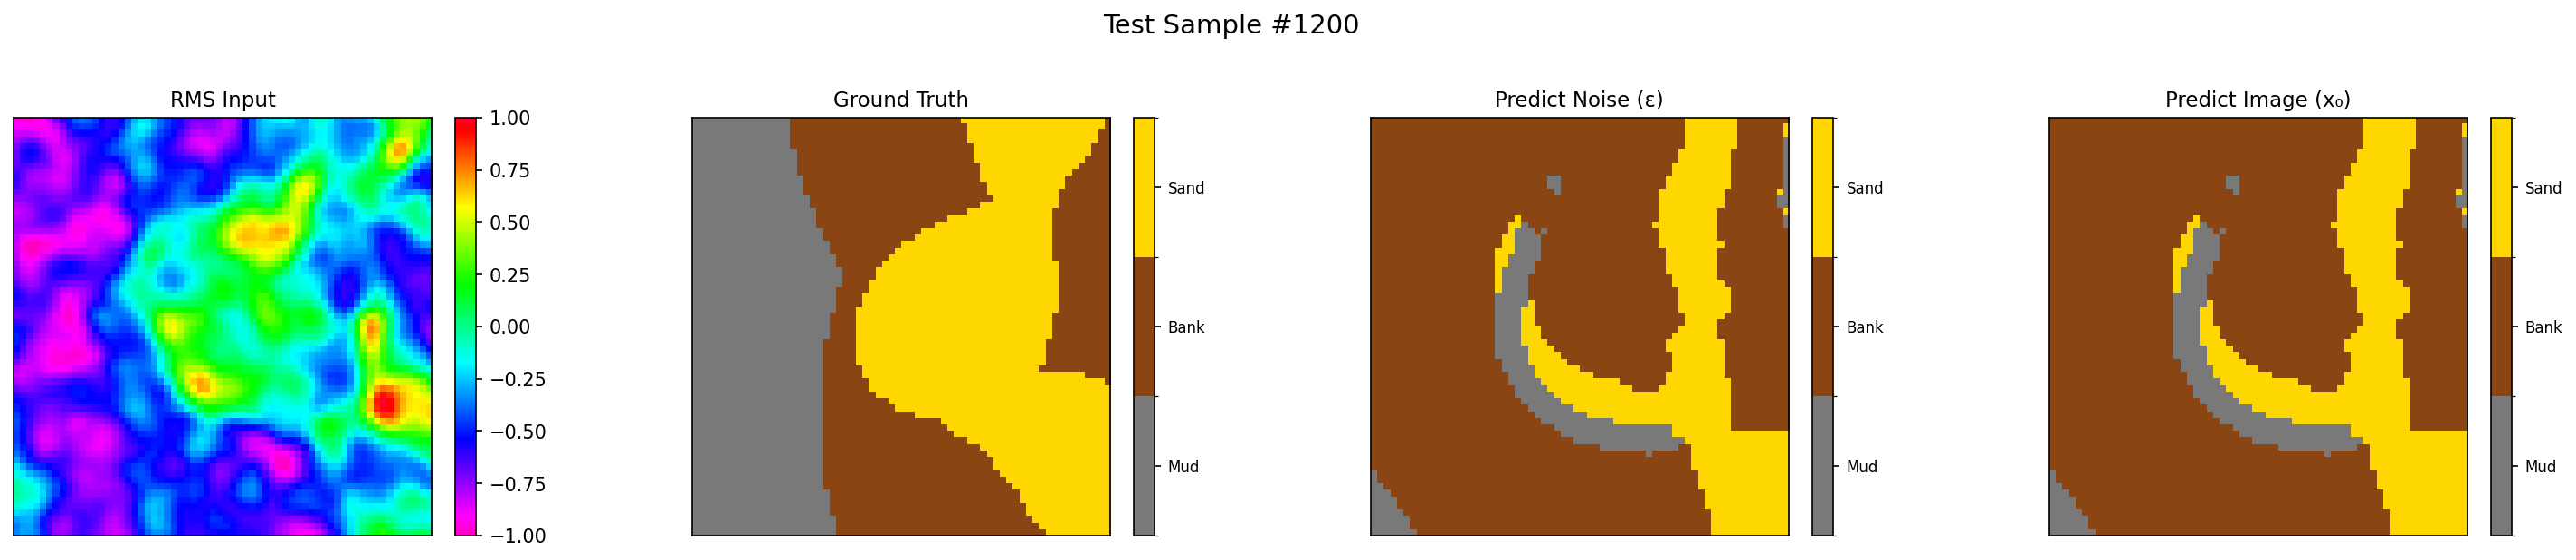

DDIM Sampling: 100%|██████████| 50/50 [00:00<00:00, 134.41it/s]


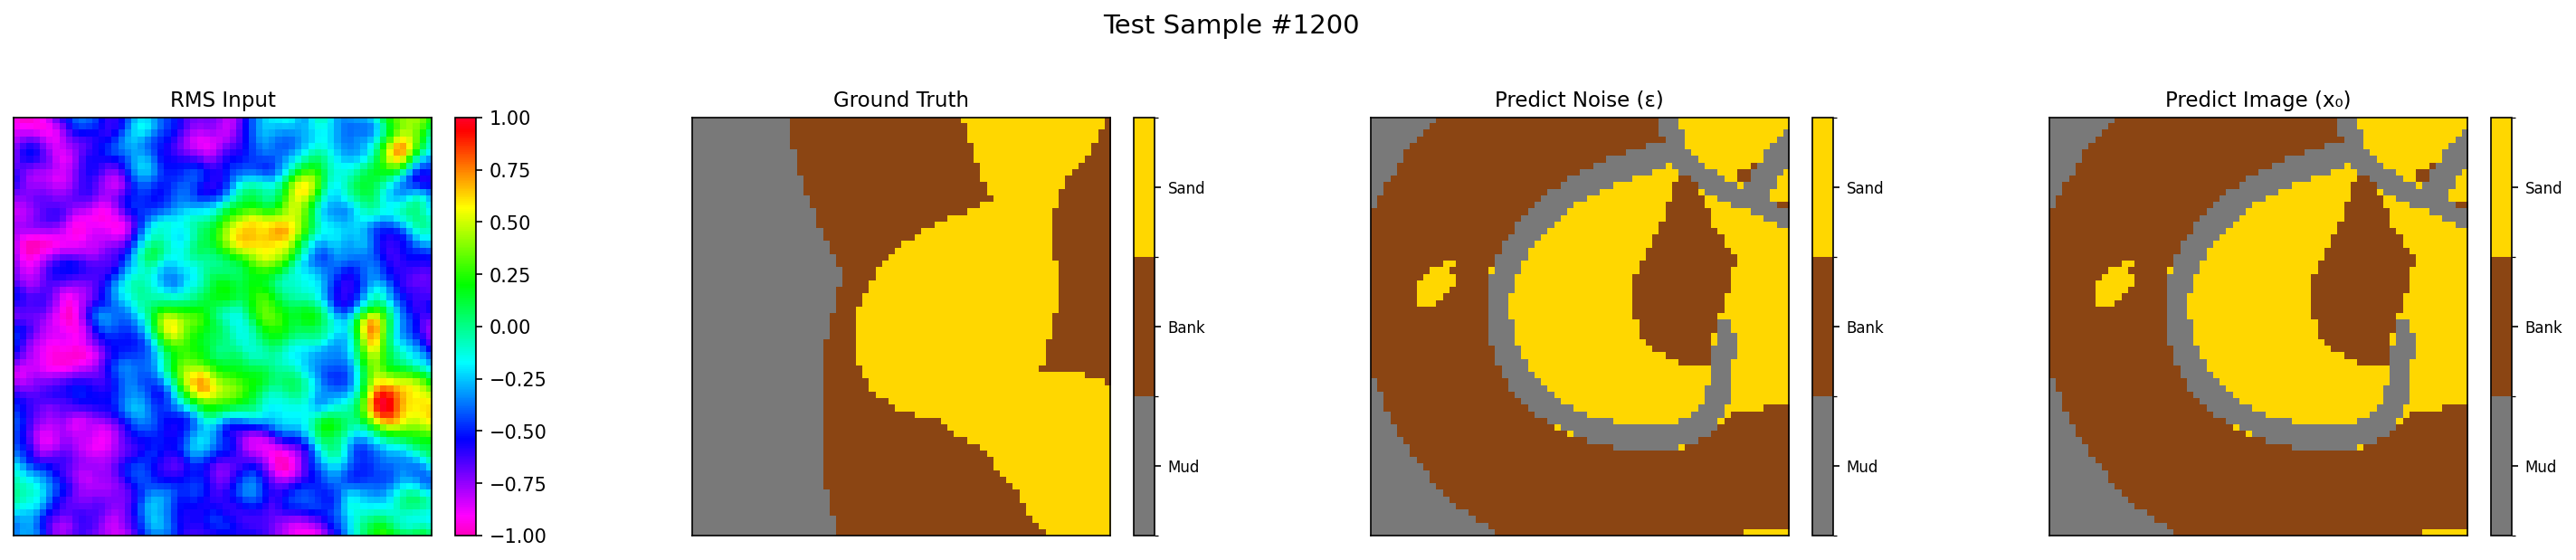

DDIM Sampling: 100%|██████████| 50/50 [00:00<00:00, 133.20it/s]


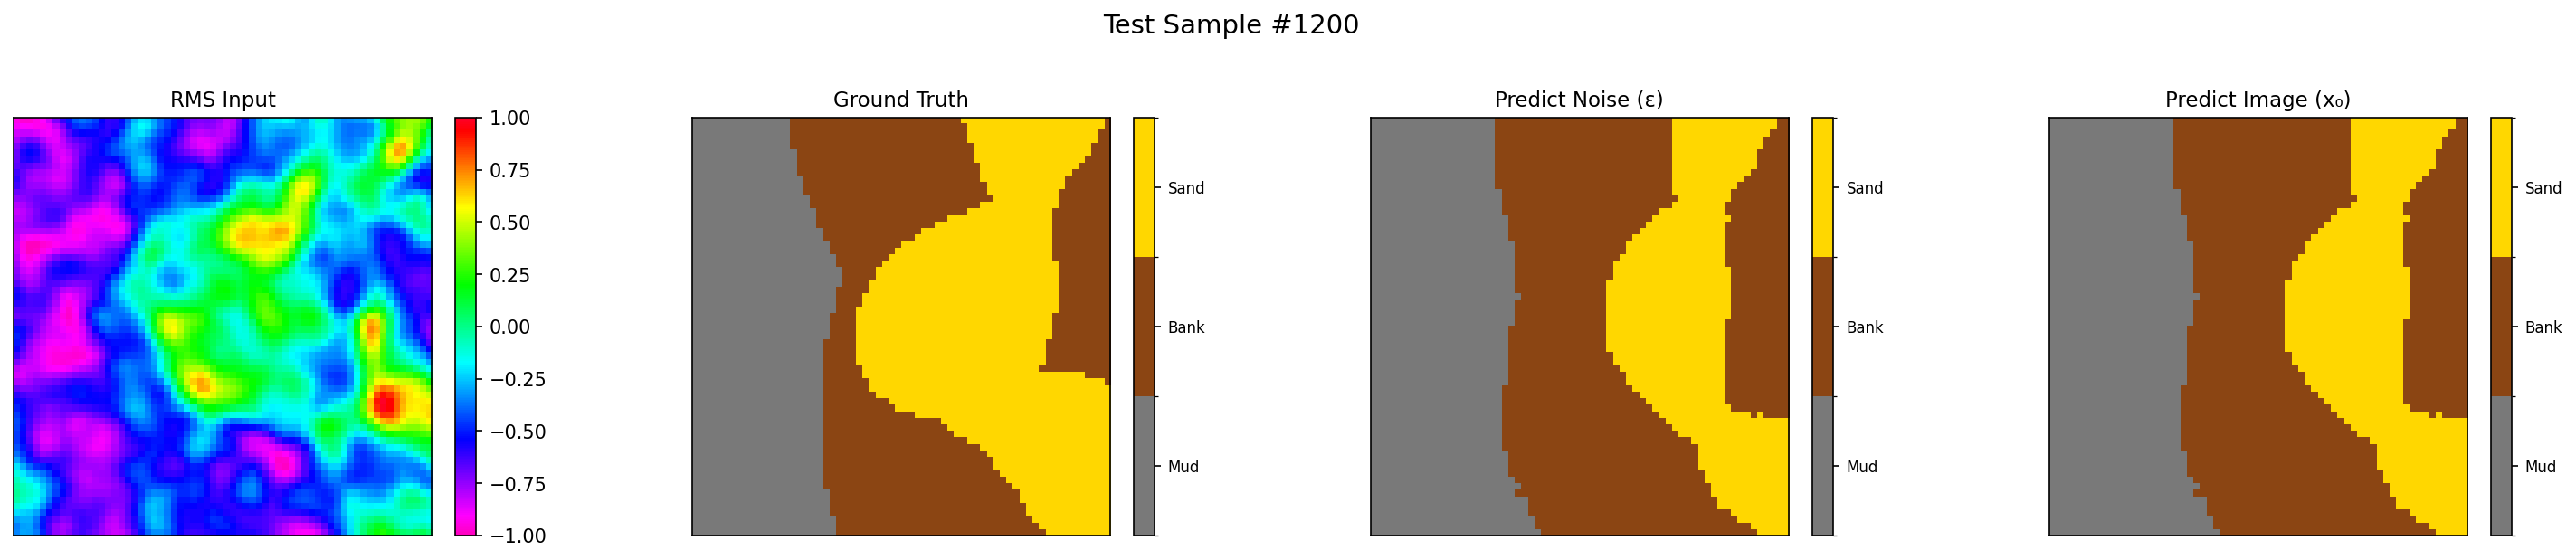

In [11]:
for i in range(10):
    fig = qc.infer_and_compare_with_rms(
        index=1200,
        use_ddim=True,
        ddim_steps=50,
        seed=i,
        figsize=(20, 4),
        # save_path="../assets/comparison_sample_0.png",
    )

DDIM Sampling: 100%|██████████| 50/50 [00:00<00:00, 129.76it/s]


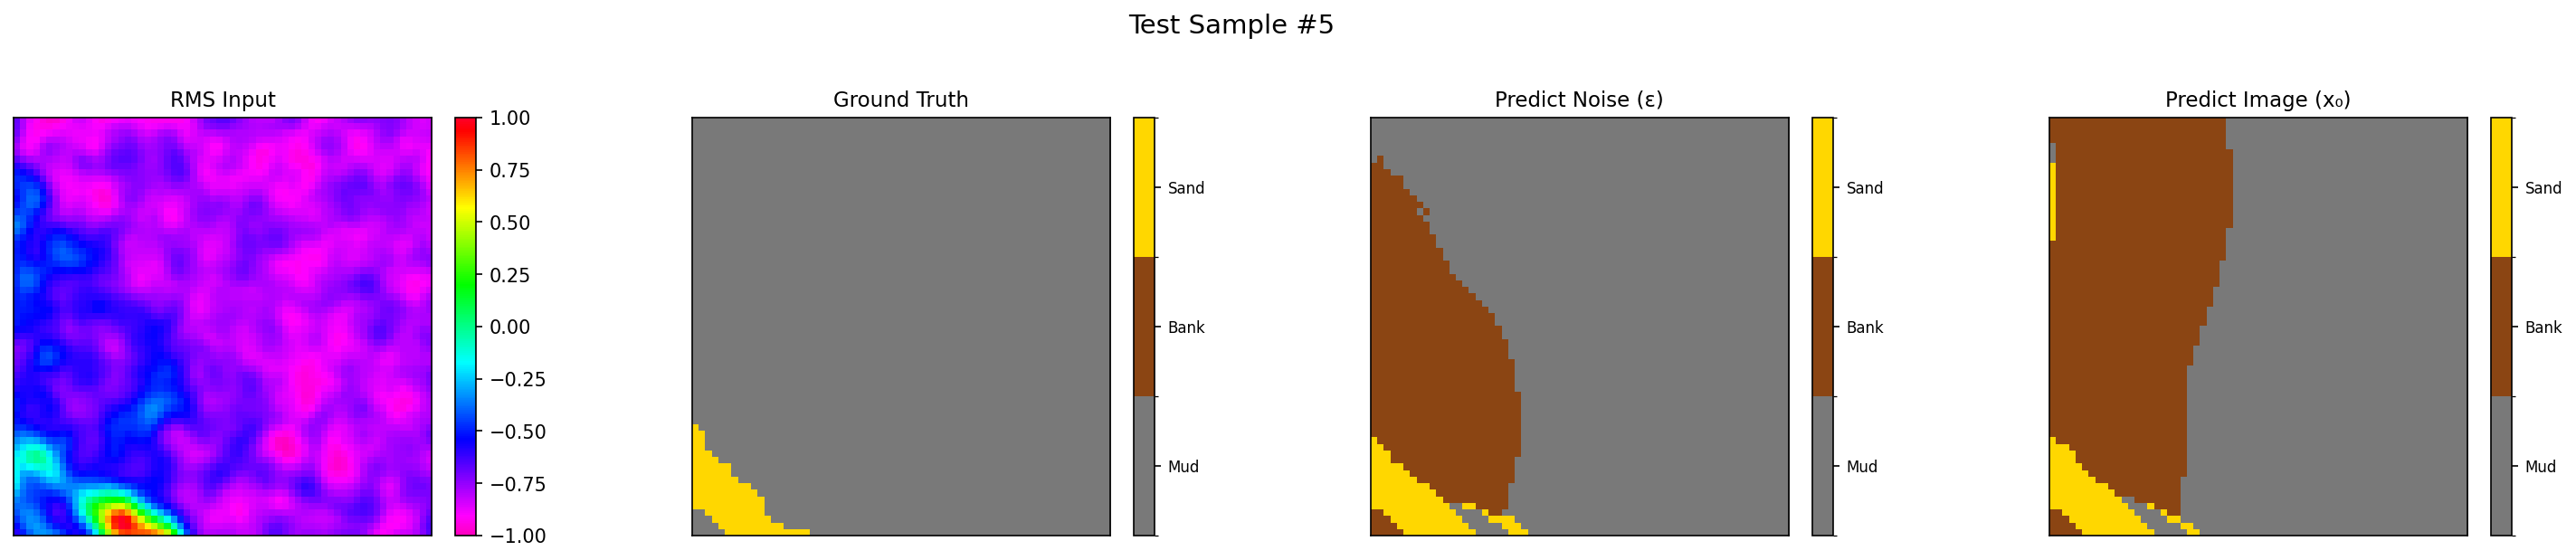

In [16]:
# Try another sample
fig = qc.infer_and_compare_with_rms(
    index=5,
    seed=42,
    # save_path="../assets/comparison_sample_5.png",
)

## 5. Batch Comparison Grid
Multiple samples in a single figure (good for slides).

DDIM Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

DDIM Sampling: 100%|██████████| 50/50 [00:00<00:00, 136.90it/s]


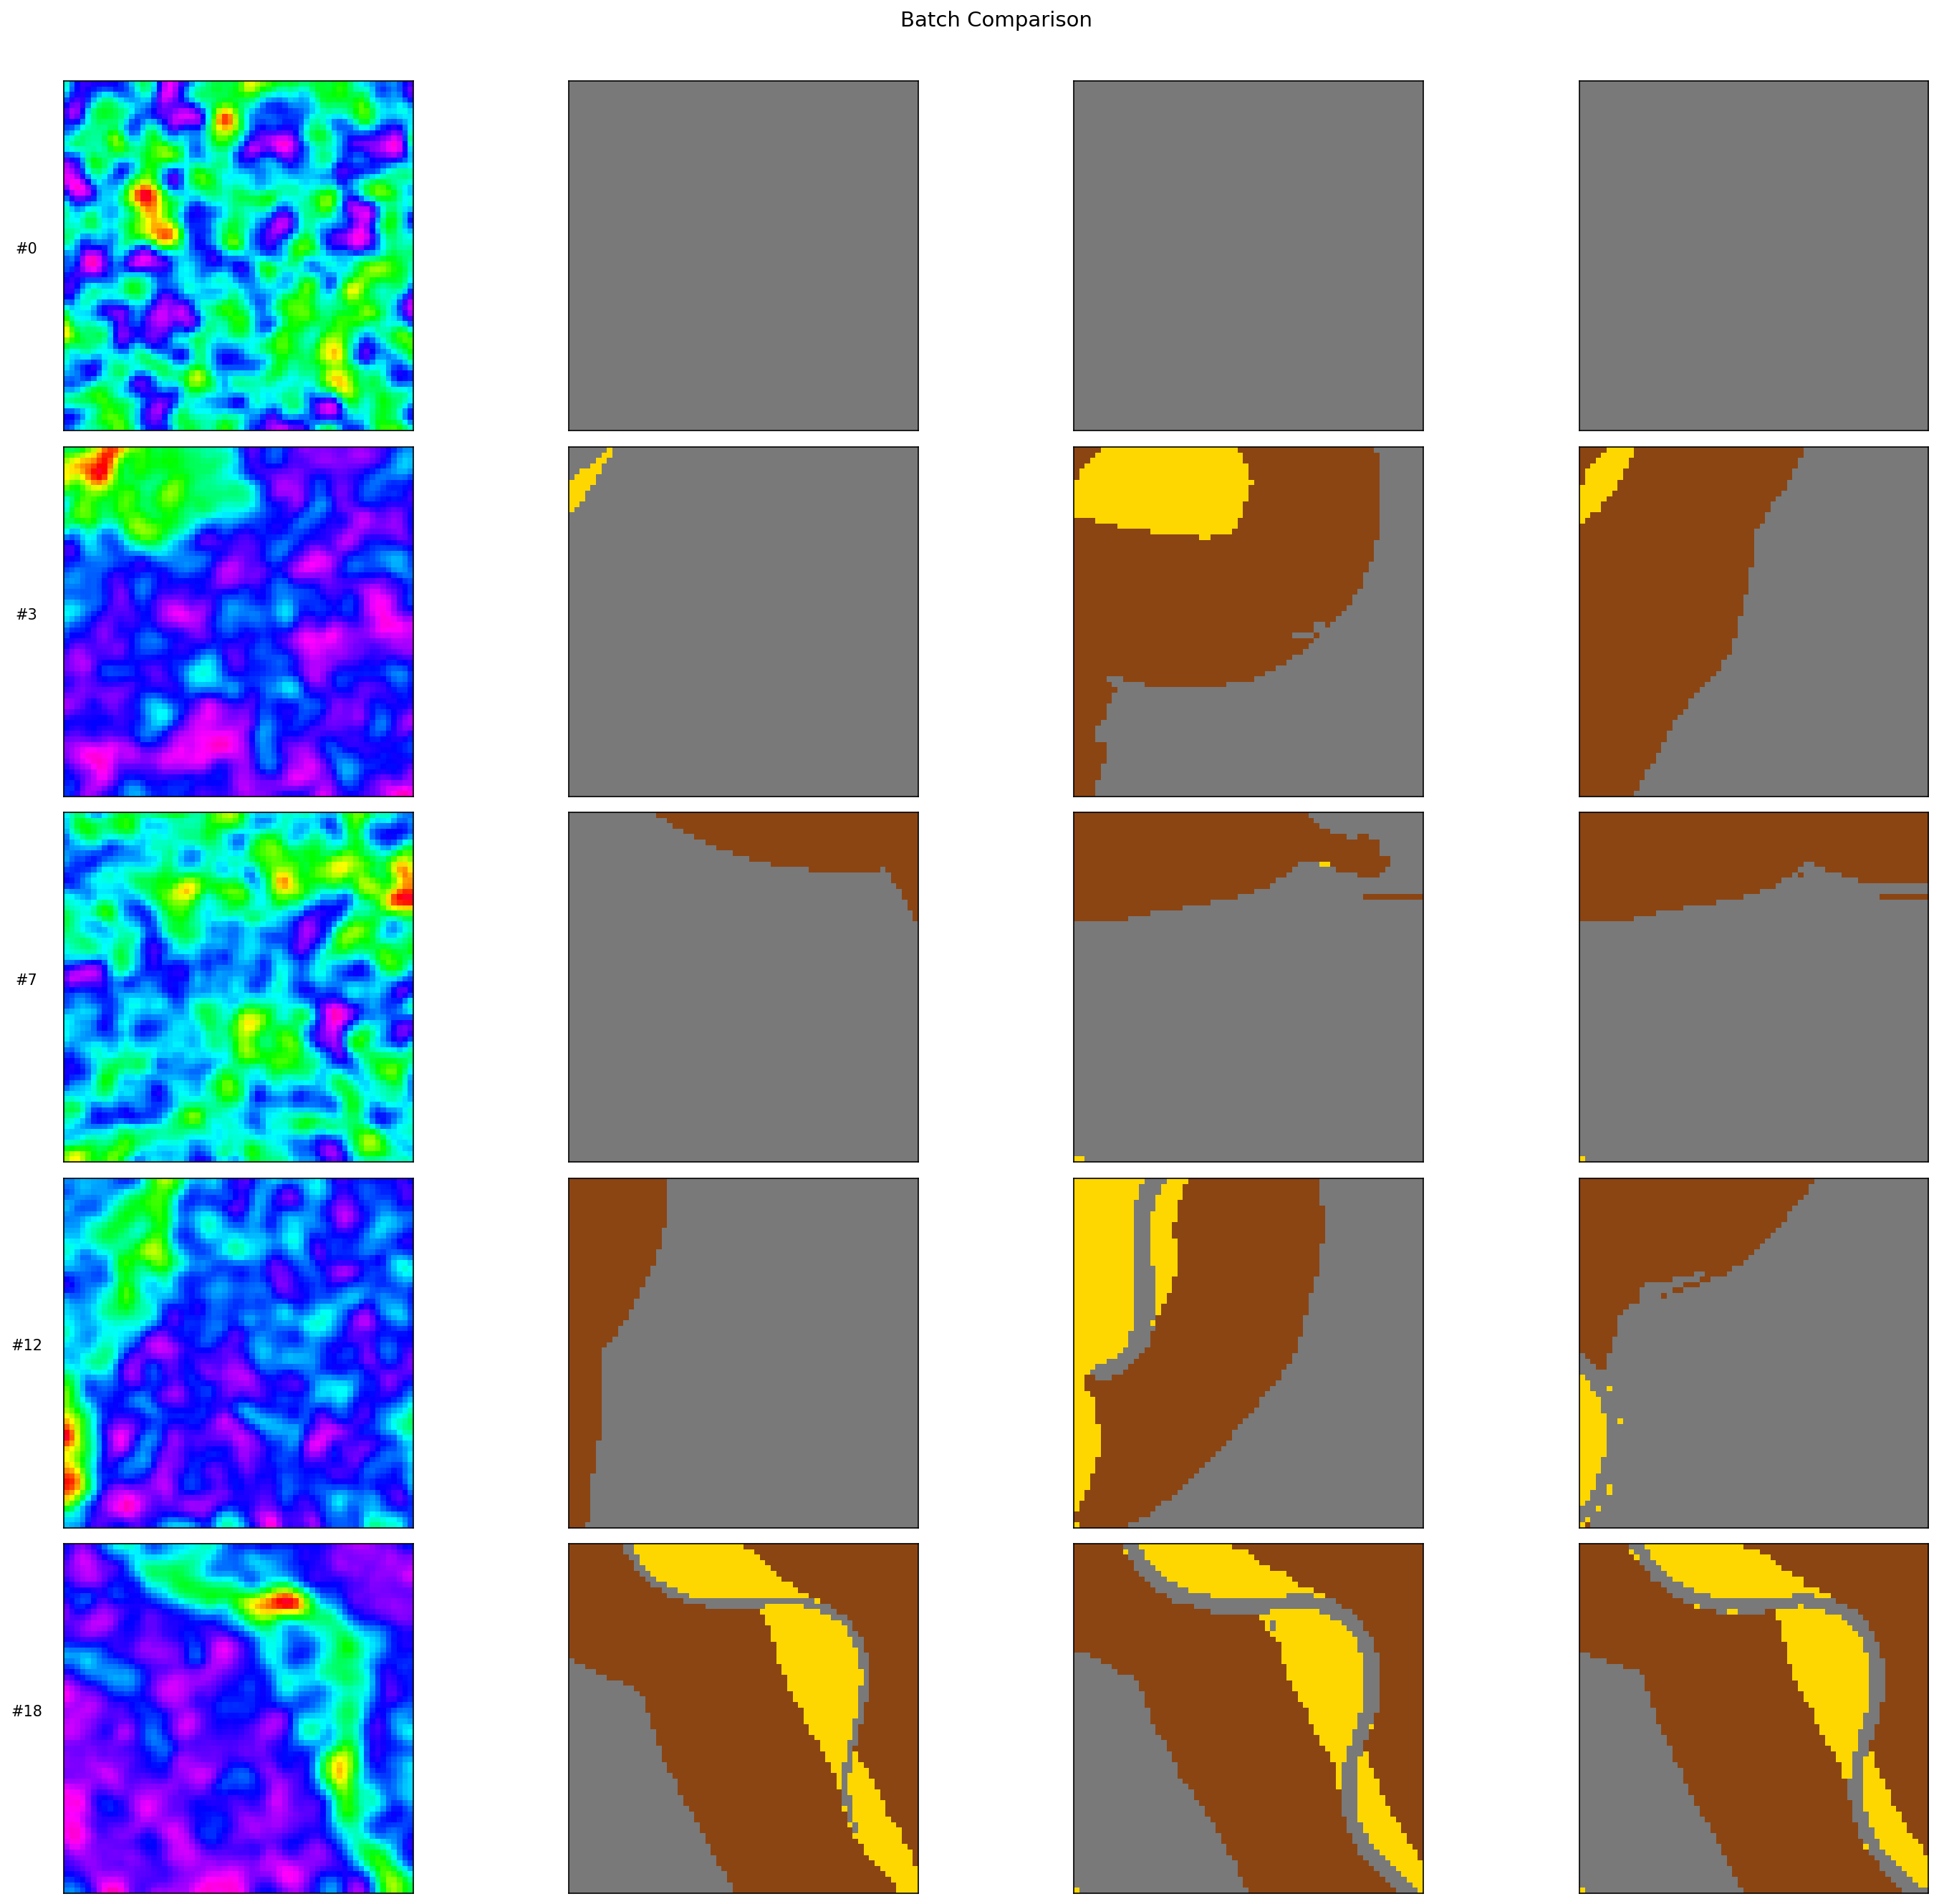

In [17]:
fig = qc.batch_compare(
    indices=[0, 3, 7, 12, 18],
    use_ddim=True,
    ddim_steps=50,
    seed=42,
    # save_path="../assets/batch_comparison.png",
)

DDIM Sampling:  28%|██▊       | 14/50 [00:00<00:00, 131.84it/s]

DDIM Sampling: 100%|██████████| 50/50 [00:00<00:00, 134.00it/s]


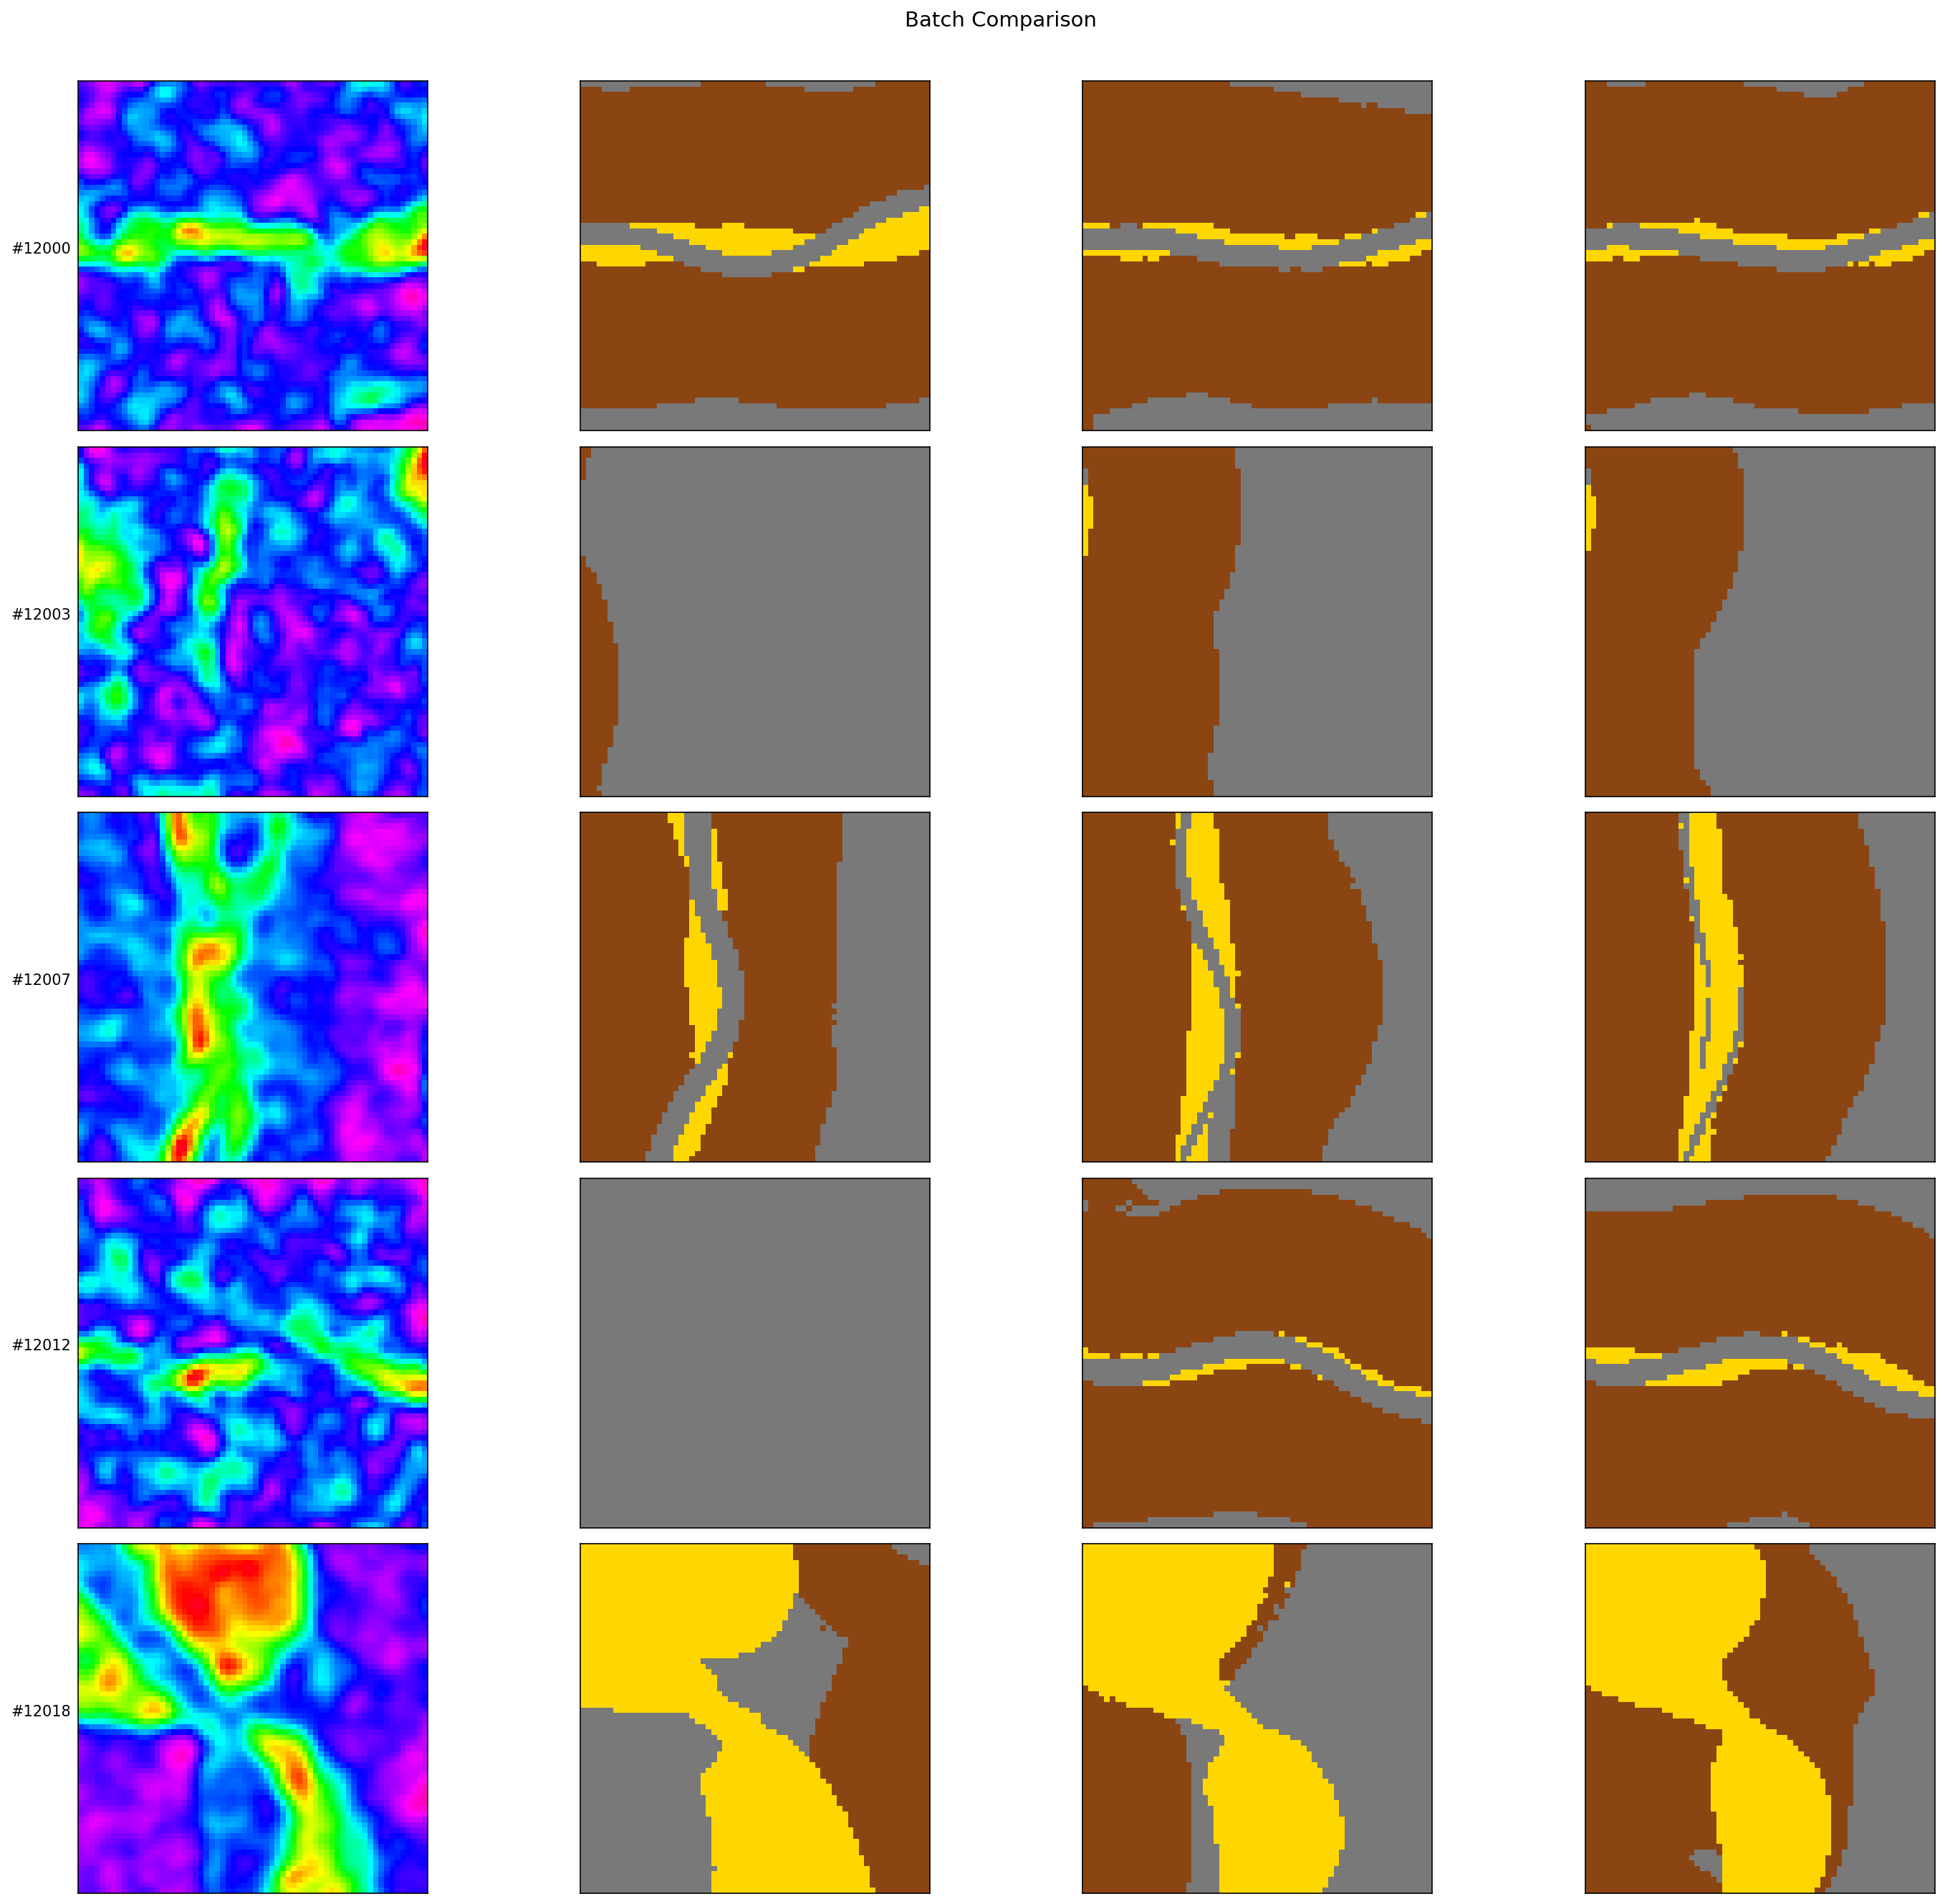

In [18]:
fig = qc.batch_compare(
    indices=[12000 + i for i in [0, 3, 7, 12, 18]],
    use_ddim=True,
    ddim_steps=50,
    seed=42,
    # save_path="../assets/batch_comparison.png",
)

## 6. Facies Proportions
Compare facies distribution (mud/bank/sand %) between GT and both models.

DDIM Sampling: 100%|██████████| 50/50 [00:00<00:00, 131.10it/s]


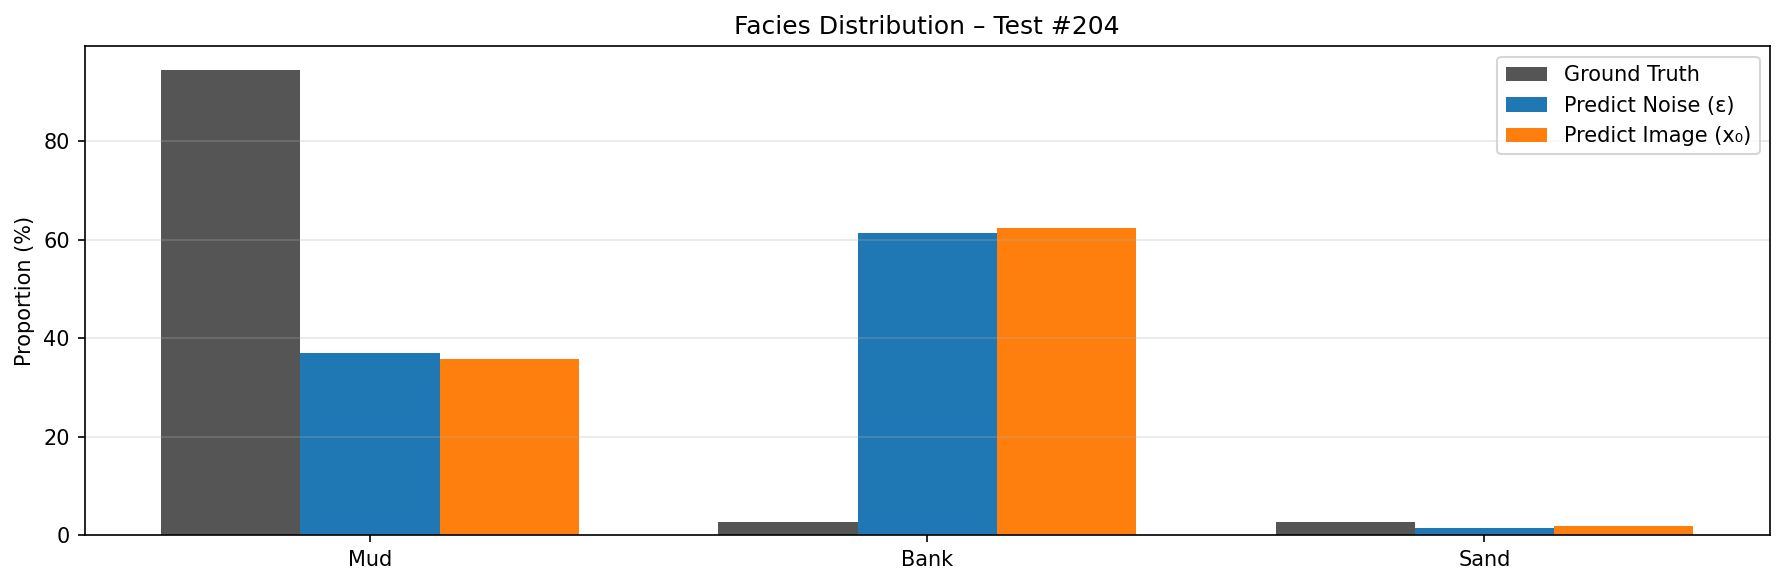

In [ ]:
for i in range(10):
    fig = qc.plot_facies_distribution(
        index=204+i,
        seed=42,
        # save_path="../assets/facies_distribution.png",
    )

## 7. Inference from an Arbitrary RMS File
Load a standalone `.npy` RMS map and generate facies from both models.

In [20]:
# Point to any RMS .npy file
rms_file = "../data/flumy_dataset/test/rms/" + os.listdir("../data/flumy_dataset/test/rms/")[0]
print(f"Using RMS file: {rms_file}")

fig = qc.infer_from_rms_file(
    rms_path=rms_file,
    seed=42,
    # save_path="../assets/inference_external_rms.png",
)

FileNotFoundError: [Errno 2] No such file or directory: '../data/flumy_dataset/test/rms/'

## 8. Save All Figures for Slides
Uncomment and run to export all figures at once.

In [ ]:
# output_dir = "../assets/qc_figures"
# os.makedirs(output_dir, exist_ok=True)
#
# qc.plot_losses(save_path=f"{output_dir}/loss_comparison.png")
# qc.plot_input_data(index=0, num_samples=4, save_path=f"{output_dir}/input_data.png")
# qc.infer_and_compare_with_rms(index=0, seed=42, save_path=f"{output_dir}/compare_sample0.png")
# qc.batch_compare(indices=[0, 3, 7, 12, 18], seed=42, save_path=f"{output_dir}/batch_grid.png")
# qc.plot_facies_distribution(index=0, seed=42, save_path=f"{output_dir}/facies_dist.png")
# print(f"All figures saved to {output_dir}/")